# Loading

In [ ]:

%pip install matplotlib pandas pyfixest statsmodels seaborn geopandas adjustText jinja2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 11.3 MB/s  0:00:00eta 0:00:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 63.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 76.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 79.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 28.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 71.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 78.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 607.2/607.2 kB 54.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 92.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 84.1 MB/s  0:00:00m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 82.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 32.5/32.5 MB 99.6 MB/s  0:00:00m eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 83.1 MB/

In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd
import os
import geopandas as gpd
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.colors as mcolors
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import argparse
from pathlib import Path
import seaborn as sns
import statsmodels.api as sm
import pyfixest as pf
from adjustText import adjust_text
from matplotlib.colors import Normalize,BoundaryNorm

K = -1
merge_idf = True



# # Set the width of your LaTeX document in points
document_width_pt = 511.  # Adjust this according to your LaTeX template
#plt.rc('text', usetex=True)
plt.rc('font', family='serif')
toulouse_color = (132/255, 46/255, 27/255)
missing_color = (0/255, 0/255, 0/255)
label_size = 18
font_size = 15  # Adjust according to your preference
plt.rcParams.update({
    "font.size": font_size,
    "axes.labelsize": font_size,
    "axes.titlesize": font_size+2,
    "xtick.labelsize": font_size-3,
    "ytick.labelsize": font_size-3,
    "legend.fontsize": font_size-3,
    "legend.title_fontsize": font_size,
    "figure.titlesize": font_size,
})


from matplotlib.colors import Normalize,BoundaryNorm
def plot_map(df, col_name, ax, fig, vmin=None, vmax=None, ze_shocked=None, add_cbar=True, norm=None, cmap="viridis",fmt_colorbar = '%1.4f',missing_color = "grey",title_cbar = None):
    
    tmp = france.merge(df, on="ze2010", how="left")
    
    tmp[col_name].fillna(0, inplace=True)
    #return tmp
    
    if vmin is None:
        vmin = df.query(f'{col_name} > 0')[col_name].min()
    if vmax is None:
        vmax = df[col_name].max()
    
    if norm is None:
        norm = mcolors.LogNorm(vmin=vmin, vmax=vmax)

    if tmp.query(f' {col_name} == 0').shape[0] > 0:
        tmp.query(f'{col_name} == 0').plot(facecolor=missing_color, ax=ax, edgecolor="black")
    tmp.query(f'{col_name} > 0').plot(column=col_name, ax=ax, norm=norm, cmap=cmap, edgecolor="black")
    
    # Inset for IDF
    if not merge_idf:
        ax_inset = inset_axes(ax, width="65%", height="65%", loc="upper right",
                              bbox_to_anchor=(0.745, 0.775, 0.25, 0.25), 
                              bbox_transform=ax.transAxes, borderpad=1)
        data_idf = tmp[tmp['ze2010'].isin(idf_ze)]
        
        if data_idf.shape[0] > 0 :data_idf.query(f'{col_name} > 0').plot(column=col_name, ax=ax_inset, norm=norm, cmap=cmap, edgecolor="black")
        ax_inset.set_xticks([])
        ax_inset.set_yticks([])
    if ze_shocked is not None:
        for ze in ze_shocked:
            tmp.query(f'ze2010 == "{ze}"').plot(facecolor="none", ax=ax, edgecolor="red", hatch="//")

        
    ax.set_xlim(-5, 10)
    ax.set_ylim(42, 52)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.axis('off')  # <-- add this line
    if add_cbar:
        add_colorbar(ax, fig, norm,cmap,fmt_colorbar,title = title_cbar)
    
    return tmp

def add_colorbar(ax,fig,norm,cmap,fmt_colorbar = '%1.4f',title = None):
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, orientation="horizontal", fraction=0.02, pad=0.04, aspect=50, format=fmt_colorbar)
    if title is not None : cbar.set_label(title)
    cbar.minorticks_off()


def get_figsize(document_width_pt = document_width_pt, wf=1, hf=0.5):
    """Parameters:
      - wf [float]:  width fraction in columnwidth units
      - hf [float]:  height fraction in columnwidth units.
                     Set by default to golden ratio.
      - columnwidth [float]: width of the column in latex. Var_sandwichet this from LaTeX 
                             using \showthe\columnwidth
    Returns:  [fig_width,fig_height]: that should be given to matplotlib
    """
    fig_width_pt = document_width_pt*wf
    inches_per_pt = 1.0/72.27               # Convert pt to inch
    fig_width = fig_width_pt*inches_per_pt  # width in inches
    fig_height = fig_width*hf      # height in inches
    return [fig_width, fig_height]



# Plots

def load_pi_r(sim_pi_r):
    pi_r = emp_pi_r
    df = pd.read_csv(input_folder / "X_dr.csv").query('X_dr > 0 & downstream_region')
    df['pi_r'] = df.X_dr/df.X_dr.sum()
    df["sim_pi_r"] = pi_r
    df.pi_r.fillna(0,inplace = True)
    df.sim_pi_r.fillna(0,inplace = True)
    return df

def plot_downstream(df,col_name,ax,fig):

    tmp = france.merge(df,on = "ze2010",how = "left")
    tmp[col_name].fillna(0,inplace = True)
    
    if col_name != "productivity":
        vmin = min(df.query('pi_r >0')["pi_r"].to_list())#+df.query('sim_pi_r >0')["sim_pi_r"].to_list())
        vmax = max(df["pi_r"].to_list()+df["sim_pi_r"].to_list())
        norm = mcolors.LogNorm(vmin=vmin, vmax=vmax)
    else: 
        vmin,vmax = min(df.query('productivity >0').productivity),max(df['productivity'])
        norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
        print(df.productivity.describe())

    tmp.query(col_name+' == 0').plot(color = "gray",ax=ax)
    tmp.query(col_name+' > 0').plot(column = col_name,ax=ax,norm = norm, cmap = "viridis",edgecolor ="black")

    ax_inset = inset_axes(ax, width="65%", height="65%", loc="upper right",bbox_to_anchor=(0.745, 0.775, 0.25, 0.25), bbox_transform=ax.transAxes, borderpad=1)  
    data_idf = tmp[tmp['ze2010'].isin(idf_ze)]
    data_idf.query(col_name+' == 0').plot(color = "gray",ax=ax_inset)
    data_idf.query(col_name+' > 0').plot(column = col_name,ax=ax_inset,norm = norm, cmap = "viridis",edgecolor ="black")

    ax_inset.set_xticks([])
    ax_inset.set_yticks([])
    ax.set_xlim(-5, 10)
    ax.set_ylim(42, 52)
    ax.set_xticks([])
    ax.set_yticks([])

    add_colorbar(ax,fig,norm,cmap = "viridis")
    return norm


def load_productivity(productivity):
    prod = productivity
    df = filter_N_upstream_df[["ze2010","pi_r"]].drop_duplicates()
    df.loc[~df.pi_r.isna(),"productivity"] = prod
    df.productivity.fillna(0,inplace = True)
    return df



def unpack_simulated_moments(sim_moments, empirical_moments):
    keys = [
        "agg_labor_share",
        "agg_industry_share",
        "emp_gamma_ls",
        "reg_coef",
        "emp_pi_r"
    ]

    sizes = [m.size for m in empirical_moments]
    splits = np.cumsum(sizes)[:-1]
    blocks = np.split(sim_moments, splits, axis=0)

    result = {}
    for k, m, b in zip(keys, empirical_moments, blocks):
        reshaped = b.reshape(m.shape + (b.shape[1],))

        # Reconstruct first element for vectors that sum to 1 

        result[k] = reshaped

    return result
    
def bubble_scatter(
    ax, x, y, xlabel, ylabel, title,
    size_scale=300,
    regression_line=False,
    weighted_regression=False,
    weights=None
):
    mask = x > 0
    x, y = x[mask], y[mask]

    sizes = size_scale * x / x.max()
    lims = [min(x.min(), y.min()) * 1.2, max(x.max(), y.max()) * 1.2]

    data = pd.DataFrame({"x": x, "y": y})

    ax.scatter(
        x, y,
        s=sizes,
        alpha=0.6,
        edgecolor="black",
        color=toulouse_color
    )

    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(linestyle="dashed", alpha=0.5)

    # -------------------
    # Regression section
    # -------------------
    if weighted_regression:
        # Default weights: proportional to x (can be changed)
        if weights is None:
            weights = x

        model = sm.WLS.from_formula(
            'y ~ 0 + x',
            data=data,
            weights=weights
        )
    else:
        model = sm.OLS.from_formula('y ~ 0 + x', data=data)

    results = model.fit()
    b = results.params.iloc[0]

    ax.text(
        0.98, 0.09,
        fr'Coefficient: ${np.round(b, 3)}$',
        ha='right', va='bottom',
        fontsize=10,
        transform=ax.transAxes
    )

    ax.text(
        0.98, 0.01,
        fr't-stat: ${np.round(results.tvalues.iloc[0], 1)}$',
        ha='right', va='bottom',
        fontsize=10,
        transform=ax.transAxes
    )

    # -------------------
    # Lines
    # -------------------
    if regression_line:
        X = np.linspace(0, lims[1], 100)
        Y = b * X
        ax.plot(X, Y, linestyle='--', color='green')
    else:
        ax.plot(lims, lims, color="black")

    sns.despine()



<>:101: SyntaxWarning: invalid escape sequence '\s'
<>:101: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_77595/2341324234.py:101: SyntaxWarning: invalid escape sequence '\s'
  using \showthe\columnwidth


In [5]:
x = np.load("../baseline_auto/emp_gamma_ls.npy")
x.shape

(10, 267)

In [7]:
import pandas as pd
import numpy as np
import geopandas as gpd
import os
from pathlib import Path


def load_industry_data(industry):
    """
    Load all necessary data for a given industry.
    
    Parameters:
    -----------
    industry : str
        Industry code (e.g., "auto", "aero")
    
    Returns:
    --------
    dict with all loaded data and derived variables
    """
    
    # =========================================================================
    # PATHS
    # =========================================================================
    input_folder = Path(f"../baseline_{industry}")
    folder = Path(f"../reporting_{industry}/")
    n_coef = np.load(os.path.join(folder,"n_reg_coef.npy"))
    gamma_threshold = np.load(os.path.join(folder,"gamma_threshold.npy"))
    
    # Downstream sector
    d = "C30C" if industry == "aero" else "C29A"
    
    # =========================================================================
    # COEFFICIENTS
    # =========================================================================
    coefs = pd.read_csv(input_folder / "stats.csv")
    agg_labor_share = coefs.loc[1, "value"]
    epsilon = coefs.loc[0, "value"]
    
    # =========================================================================
    # ARRAYS
    # =========================================================================
    
    agg_industry_share = np.load(input_folder / "input_share.npy")
    emp_gamma_ls = np.load(input_folder / "emp_gamma_ls.npy")
    emp_gamma_ls[emp_gamma_ls/np.sum(emp_gamma_ls, axis = 1,keepdims=True)<= gamma_threshold] = 0 
    emp_pi_r = pd.read_csv(input_folder / "X_dr.csv").query('X_dr > 0 & downstream_region').X_dr.values
    emp_pi_r = (emp_pi_r/emp_pi_r.sum())
    reg_coef = np.load(input_folder / f"reg_coef_4.npy") if n_coef == 4 else np.array(coefs.loc[coefs.stats == "reg_coef",'value'].values[0])
    N_downstream_per_region_local = np.load(os.path.join(input_folder,"N_downstream_per_region.npy"))
    regional_wage = np.load(input_folder / "regional_wages.npy")
    X_dr = pd.read_csv(os.path.join(input_folder / "X_dr.csv"))
    X_dr['ze2010'] = X_dr['ze2010'].astype(str).str.zfill(4)

    
    # =========================================================================
    # REFERENCE EMPIRICAL MOMENTS
    # =========================================================================
    reference_empirical_moments = [
        np.array([agg_labor_share]),
        agg_industry_share,
        emp_pi_r,
        reg_coef,
        emp_gamma_ls
    ]
    empirical_moments = np.concatenate([np.ndarray.flatten(d) for d in reference_empirical_moments]).reshape(-1,1)

    # =========================================================================
    # ILE-DE-FRANCE ZONES
    # =========================================================================
    idf_ze = [
        '1101', '1111', '1102', '1104', '1118', '1115', '1116', '1105',
        '1117', '1110', '1119', '1112', '1103', '1109', '1106', '1114',
        '1113', '1108', '1107'
    ]
    
    # =========================================================================
    # FILTER DATA
    # =========================================================================
    filter_N_upstream_df = pd.read_csv(input_folder / "filter_N_upstream.csv")
    filter_N_upstream_df['ze2010'] = filter_N_upstream_df['ze2010'].astype(str).str.zfill(4)
    
    # =========================================================================
    # DISTANCES AND GEOGRAPHY
    # =========================================================================
    distances = np.load(input_folder / "full_distances.npy")   
    
    france = gpd.read_file(input_folder / "france.gpkg", encoding='utf-8').sort_values(by='ze2010')

    
    # Build distance reference dataframe
    ref = pd.DataFrame(
        distances[:297, :297], 
        index=france["ze2010"].values, 
        columns=france["ze2010"].values
    )
    ref.reset_index(inplace=True)
    ref.rename(columns={'index': 'ze2010_i'}, inplace=True)
    ref = ref.melt(id_vars='ze2010_i', var_name='ze2010_j', value_name='M_ij')
    
    # =========================================================================
    # SIMULATED MOMENTS
    # =========================================================================
    best_simulated_moments = np.load(folder / "best_simulated_moments.npy")
    best_params = np.load(folder / "best_parameters_list.npy")
    try:
        panel_df = pd.read_parquet(folder/ "simulated_panel_unified.parquet")
        regional_panel_df = pd.read_parquet(folder/ "regional_sales_unified.parquet")
        suppliers = pd.read_parquet(folder / "suppliers.parquet")
        
    except : 
        panel_df = None
        regional_panel_df = None
        suppliers = None
    # Unpack moments
    best_simulated_moments_dict = unpack_simulated_moments(
        best_simulated_moments, 
        reference_empirical_moments
    )
    empirical_moments_dict = dict(zip([
        "agg_labor_share",
        "agg_industry_share",
        "emp_pi_r",
        "reg_coef",
        "emp_gamma_ls"
    ], reference_empirical_moments))
    
    # =========================================================================
    # RETURN ALL DATA
    # =========================================================================
    return {
        # Paths
        'input_folder': input_folder,
        'folder': folder,
        
        # Industry info
        'industry': industry,
        'industry': industry,
        'd': d,
        
        # Coefficients
        'coefs': coefs,
        'agg_labor_share': agg_labor_share,
        'epsilon': epsilon,
        'n_coef':n_coef,
        
        # Arrays
        'agg_industry_share': agg_industry_share,
        'emp_gamma_ls': emp_gamma_ls,
        'emp_pi_r': emp_pi_r,
        'reg_coef': reg_coef,
        "regional_wage":regional_wage,
        "X_dr":X_dr,
        
        # Moments
        'reference_empirical_moments': reference_empirical_moments,
        'empirical_moments': empirical_moments,
        'best_simulated_moments': best_simulated_moments,
        'best_params': best_params,
        'best_simulated_moments_dict': best_simulated_moments_dict,
        'empirical_moments_dict': empirical_moments_dict,

        # Regression 
        'panel_df':panel_df,
        "regional_panel_df":regional_panel_df,
        "suppliers":suppliers,
        
        # Geography
        'idf_ze': idf_ze,
        'filter_N_upstream_df': filter_N_upstream_df,
        "N_downstream":N_downstream_per_region_local,
        'distances': distances,
        'france': france,
        'ref': ref,
    }


# =============================================================================
# EXAMPLE USAGE
# =============================================================================
industry = "auto"
# Load data
data = load_industry_data(industry)

# Unpack variables (optional - can also access via data['variable_name'])
input_folder = data['input_folder']
folder = data['folder']
d = data['d']
agg_labor_share = data['agg_labor_share']
epsilon = data['epsilon']
agg_industry_share = data['agg_industry_share']
emp_gamma_ls = data['emp_gamma_ls']
emp_pi_r = data['emp_pi_r']
reg_coef = data['reg_coef']
reference_empirical_moments = data['reference_empirical_moments']
idf_ze = data['idf_ze']
filter_N_upstream_df = data['filter_N_upstream_df']
distances = data['distances']
france = data['france']
ref = data['ref']
n_coef = data['n_coef']
empirical_moments = data['empirical_moments']
best_simulated_moments = data['best_simulated_moments']
best_params = data['best_params']
best_simulated_moments_dict = data['best_simulated_moments_dict']
empirical_moments_dict = data['empirical_moments_dict']
panel_df = data['panel_df']
regional_panel_df = data['regional_panel_df']
suppliers = data['suppliers']
N_downstream = data['N_downstream']
X_dr = data['X_dr']

# Or use a helper to unpack all at once
def unpack_data(data_dict):
    """Unpack data dictionary into global namespace."""
    return data_dict.values()

# Or more elegantly with locals().update() in a notebook:
# locals().update(data)

/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


In [8]:

def unpack_simulated_moments(sim_moments, empirical_moments):
    keys = [
        "agg_labor_share",
        "agg_industry_share",
        "emp_pi_r",
        "reg_coef",
        "emp_gamma_ls"
    ]

    sizes = [m.size for m in empirical_moments]
    splits = np.cumsum(sizes)[:-1]
    blocks = np.split(sim_moments, splits, axis=0)

    result = {}
    for k, m, b in zip(keys, empirical_moments, blocks):
        reshaped = b.reshape(m.shape + (b.shape[1],))

        # Reconstruct first element for vectors that sum to 1 

        result[k] = reshaped

    return result

# Reporting

## Merging reporting tables

In [4]:
import os
import numpy as np
import pandas as pd
from pathlib import Path

# Assuming unpack_simulated_moments is defined elsewhere in your codebase
# from your_module import unpack_simulated_moments


def generate_combined_table(industries_config, output_file="moments_comparison_combined.tex"):
    """
    Generate a combined LaTeX table with subcolumns for multiple industries.
    
    Parameters:
    -----------
    industries_config : list of dict
        Each dict contains: 'industry', 'industry', 'display_name'
        Example: [{'industry': 'auto', 'industry': 'auto', 'display_name': 'Car'},
                  {'industry': 'aero', 'industry': 'aero', 'display_name': 'Aerospace'}]
    output_file : str
        Path to the output LaTeX file.
    n_reg_coef : int
        Number of regression coefficients to display (4 or 5). 
        If 4, the ]20,50] bin is excluded. Default is 5.
    """
    K = -1  # Use last iteration
    
    # Load data for all industries
    all_data = {}
    for config in industries_config:
        industry = config['industry']
        industry = config['industry']
        all_data[industry] = load_industry_data(industry)

    n_reg_coef = len(all_data['aero']['reg_coef'])
    # Load industry names
    name_A129 = pd.read_csv("../external/A129_name_fr_eng.csv")
    
    # Number of industries
    n_industries = len(industries_config)
    
    # Build column spec for siunitx
    col_spec = "l " + " ".join(["S[table-format=1.4] S[table-format=1.4]" for _ in range(n_industries)])
    
    # Build header with multicolumn for each industry
    header_row1 = " & " + " & ".join([f"\\multicolumn{{2}}{{c}}{{{config['display_name']}}}" for config in industries_config]) + " \\\\"
    
    # Cmidrule for each industry pair
    cmidrules = ""
    for i, _ in enumerate(industries_config):
        start_col = 2 + i * 2
        end_col = start_col + 1
        cmidrules += f"\\cmidrule(lr){{{start_col}-{end_col}}} "
    
    header_row2 = " & " + " & ".join(["{Emp.} & {Sim.}" for _ in industries_config]) + " \\\\"
    
    # === Panel A: Aggregate Labor Share ===
    panel_A_rows = []
    row_data = ["Aggregate Labor Share"]
    for config in industries_config:
        industry = config['industry']
        data = all_data[industry]
        emp_val = np.round(data['agg_labor_share'], 4)
        sim_val = np.round(data['best_simulated_moments_dict']['agg_labor_share'][:, K][0], 4)
        row_data.extend([emp_val, sim_val])
    panel_A_rows.append(row_data)
    
    # === Panel B: Aggregate Industry Shares ===
    # Get union of all A129 codes across industries
    all_A129_codes = set()
    for config in industries_config:
        industry = config['industry']
        data = all_data[industry]
        codes = list(data['filter_N_upstream_df']['A129'].drop_duplicates().sort_values())
        all_A129_codes.update(codes)
    all_A129_codes = sorted(all_A129_codes)
    
    # Create industry share dataframes for each industry
    industry_shares = {}
    for config in industries_config:
        industry = config['industry']
        data = all_data[industry]
        A129_codes = list(data['filter_N_upstream_df']['A129'].drop_duplicates().sort_values())
        sim_shares = list(data['best_simulated_moments_dict']['agg_industry_share'][:, K])
        industry_shares[industry] = pd.DataFrame({
            "A129": A129_codes,
            "Empirical": list(np.round(data['agg_industry_share'], 4)),
            "Simulated": np.round(sim_shares, 4)
        })
    
    # Build Panel B rows
    panel_B_rows = []
    for code in all_A129_codes:
        sector_name = name_A129[name_A129['A129'] == code]['name'].values
        sector_name = sector_name[0] if len(sector_name) > 0 else "Non-upstream sector"
        
        row_data = [sector_name]
        for config in industries_config:
            industry = config['industry']
            df = industry_shares[industry]
            match = df[df['A129'] == code]
            if len(match) > 0:
                emp_val = match.iloc[0]['Empirical']
                sim_val = match.iloc[0]['Simulated']
            else:
                emp_val, sim_val = "---", "---"
            row_data.extend([emp_val, sim_val])
        panel_B_rows.append(row_data)
    
    # === Panel C: Regression Coefficients ===
    # Define coefficient names based on n_reg_coef parameter
    all_coef_names_full = [r'$]20,50]$', r'$]50,100]$', r'$]100,150]$', r'$]150,200]$', r'$>200$']
    
    if n_reg_coef == 4:
        # Exclude the first bin (]20,50])
        all_coef_names = all_coef_names_full[1:]
    else:
        # Use all 5 bins
        all_coef_names = all_coef_names_full
    
    panel_C_rows = []
    for i, coef_name in enumerate(all_coef_names):
        row_data = [coef_name]
        for config in industries_config:
            industry = config['industry']
            data = all_data[industry]
            
            # Determine which coefficient index to use
            coef_idx = i
            
            if coef_idx < len(data['reg_coef']):
                emp_val = np.round(data['reg_coef'][coef_idx], 3)
                sim_val = np.round(data['best_simulated_moments_dict']['reg_coef'][:, K][coef_idx], 3)
            else:
                emp_val, sim_val = "---", "---"
            row_data.extend([emp_val, sim_val])
        panel_C_rows.append(row_data)
    
    # === Generate LaTeX Table ===
    def format_value(val, decimals=4):
        """Format a value for LaTeX, handling '---' for missing data."""
        if val == "---" or (isinstance(val, float) and np.isnan(val)):
            return "{---}"
        return f"{val:.{decimals}f}"
    
    latex_table = r"""\begin{table}[H]
\centering
\caption{Empirical and Simulated Moments: Comparison Across Industries}
\label{tab:moments_comparison_combined}
\renewcommand{\arraystretch}{1.2}
\small
\begin{tabular}{""" + col_spec + r"""}
\toprule
""" + header_row1 + "\n" + cmidrules + "\n" + header_row2 + "\n"
    
    # Panel A
    latex_table += "\\midrule\n"
    latex_table += f"\\multicolumn{{{1 + 2*n_industries}}}{{l}}{{\\textbf{{Panel A: Aggregate Labor Share}}}} \\\\\n"
    latex_table += "\\midrule\n"
    for row in panel_A_rows:
        row_str = row[0] + " & " + " & ".join([format_value(v, 4) for v in row[1:]]) + " \\\\\n"
        latex_table += row_str
    
    # Panel B
    latex_table += "\\midrule\n"
    latex_table += f"\\multicolumn{{{1 + 2*n_industries}}}{{l}}{{\\textbf{{Panel B: Aggregate Industry Shares}}}} \\\\\n"
    latex_table += "\\midrule\n"
    for row in panel_B_rows:
        row_str = row[0] + " & " + " & ".join([format_value(v, 4) for v in row[1:]]) + " \\\\\n"
        latex_table += row_str
    
    # Panel C
    latex_table += "\\midrule\n"
    latex_table += f"\\multicolumn{{{1 + 2*n_industries}}}{{l}}{{\\textbf{{Panel C: Regression Coefficients}}}} \\\\\n"
    latex_table += "\\midrule\n"
    for row in panel_C_rows:
        row_str = row[0] + " & " + " & ".join([format_value(v, 3) for v in row[1:]]) + " \\\\\n"
        latex_table += row_str
    
    latex_table += "\\bottomrule\n"
    latex_table += r"""\end{tabular}

\vspace{0.3cm}
\caption*{\footnotesize \emph{Notes}: This table compares empirical moments with moments simulated from the model calibrated on each industry. ``Emp.'' = Empirical, ``Sim.'' = Simulated. Panel~A shows the aggregate labor share, Panel~B shows sectoral industry shares, and Panel~C shows regression coefficients estimated empirically using Equation~\ref{eq:reduced_form_spatialIO} on finer distance bins. ``---'' indicates the moment is not applicable for that industry. Shares are rounded to 4 decimals, coefficients to 3 decimals.}
\end{table}
"""
    
    # Save to file
    with open(output_file, "w") as f:
        f.write(latex_table)
    
    print(f"Combined table saved to: {output_file}")
    return latex_table


# === Main execution ===
if __name__ == "__main__":
    # Define industries to compare
    industries_config = [
        {'industry': 'auto', 'industry': 'auto', 'display_name': 'Motor Vehicles'},
        {'industry': 'aero', 'industry': 'aero', 'display_name': 'Aerospace'}
    ]
    
    # Generate combined table
    output_folder = "../reporting_combined/"
    os.makedirs(output_folder, exist_ok=True)
    
    latex_output = generate_combined_table(
        industries_config,
        output_file=os.path.join(output_folder, "moments_comparison_combined.tex")
    )
    
    print(latex_output)

/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


FileNotFoundError: [Errno 2] No such file or directory: '../reporting_gmm_aero/n_reg_coef.npy'

## Table, maps and scatter plots

In [ ]:

for industry in ['auto','aero']:
    data = load_industry_data(industry)
    globals().update(data)  # In a script

    emp_g = empirical_moments_dict['emp_gamma_ls'].ravel()
    sim_g = best_simulated_moments_dict['emp_gamma_ls'][:, :, K].ravel()
    sim_g = sim_g[emp_g!=0]
    emp_g = emp_g[emp_g!=0]
            
    fig, axs = plt.subplots(1, 1, figsize=get_figsize())

    bubble_scatter(
        axs,
        emp_g,
        sim_g,
        r"Empirical",
        r"Simulated",
        None,regression_line = False
    )

    fig.savefig(os.path.join("../reporting_combined", f'emp_sim_gamma_{industry}.pdf'), format='pdf', bbox_inches='tight')

    fig, axs = plt.subplots(1, 1, figsize=get_figsize())


    emp_pi_r = empirical_moments_dict['emp_pi_r'].ravel()
    sim_pi_r = best_simulated_moments_dict['emp_pi_r'][:, K].ravel()

    bubble_scatter(
        axs,
        emp_pi_r,
        sim_pi_r,
        r"Empirical",
        r"Simulated",
        None,
        size_scale=400,regression_line = False
    )
    fig.savefig(os.path.join("../reporting_combined", f'emp_sim_pi_{industry}.pdf'), format='pdf', bbox_inches='tight')


## Untargeted

In [ ]:
industry = "aero"

data = load_industry_data(industry)
globals().update(data)  # In a script

tmp = filter_N_upstream_df[['ze2010']].drop_duplicates()
tmp['N_downstream'] = N_downstream
tmp.sort_values(by = 'N_downstream',inplace = True)

sector_names = filter_N_upstream_df[['A129']].drop_duplicates().sort_values(by = "A129").reset_index()
sector_names.index +=1 
sector_names = sector_names['A129'].to_dict()

ze_names = filter_N_upstream_df[['ze2010']].drop_duplicates().sort_values(by = "ze2010").reset_index()
ze_names.index +=1 
ze_names = ze_names['ze2010'].to_dict()

ze_df = filter_N_upstream_df['ze2010'].drop_duplicates().sort_values().reset_index()
ze_df['index'] +=1
ze_df['N_downstream'] = N_downstream
ze_downstream = ze_df.query('N_downstream > 0').rename(columns = {"ze2010":"ze2010_downstream"})
regions = np.sort(filter_N_upstream_df.ze2010.unique())


distance_matrix = np.load(os.path.join(input_folder, "distances.npy"))
distance_matrix = pd.DataFrame(distance_matrix, index=regions, columns=france.ze2010)
distance_matrix = distance_matrix.reset_index()
distance_matrix = distance_matrix.melt(
id_vars="index",
var_name="ze2010_shocked",
value_name="distance"
)
distance_matrix = distance_matrix.rename(columns = {"index":"ze2010"})
distance_matrix['ze2010'] = distance_matrix['ze2010'].astype(str).str.zfill(4)
distance_matrix['ze2010_shocked'] = distance_matrix['ze2010_shocked'].astype(str).str.zfill(4)


# The supplier dataset only encodes the linkages. We add the shares equal to 0. 
df = pd.read_parquet(f"../reporting_{industry}/suppliers.parquet")
df.rename(columns = {"ze2010_downstream":"ze2010_shocked"},inplace = True)
df['ze2010_shocked'] = df.ze2010_shocked.map(ze_names)
df['ze2010'] = df.ze2010.map(ze_names)
df['A129'] = df.A129.map(sector_names)


# X_{i→r} = share × downstream_purchase  (= share × μ × Y_r)
df['X_ir'] = df['share'] * df['downstream_purchase']
# For zero-filled rows, share=0 so X_ir=0 regardless of missing downstream_purchase

total_by_firm = df.groupby('SIREN')['X_ir'].sum().rename('total_X')
df = df.merge(total_by_firm, on='SIREN')
df['a_ir'] = np.where(df['total_X'] > 0, df['X_ir'] / df['total_X'], 0.0)

extended_df = df[['ze2010_shocked']].drop_duplicates().merge(df[['SIREN']].drop_duplicates(),how = "cross").merge(df[['ze2010_shocked','SIREN','a_ir']],on = ["ze2010_shocked","SIREN"],how  = "left")
df = extended_df.merge(df[['SIREN','A129','ze2010','productivity',"sample_weight"]].drop_duplicates(),on = "SIREN",how ="left")
df['sector_downstream'] = df['A129'] + "-" + df['ze2010_shocked']

df = df.merge(distance_matrix,on = ['ze2010','ze2010_shocked'])
df.a_ir = df.a_ir.fillna(0)


# Prepare regression variables
df['log_distance'] = np.log(df['distance'].clip(lower=1))  
df['log_productivity'] = np.log(df['productivity'].clip(lower=1))  
# PPML: share_ir = exp(α_{s×r} + η·log(dist) + controls) + ε

m = pf.fepois(
    fml="a_ir ~ log_distance + log_productivity | sector_downstream",
    data=df,
    weights="sample_weight",
    vcov={"CRV1": "ze2010"}
)
m.summary()

### Sales distribution

In [ ]:


for industry in ['auto','aero']:
    data = load_industry_data(industry)
    globals().update(data)  # In a script

    sector_names = filter_N_upstream_df[['A129']].drop_duplicates().sort_values(by = "A129").reset_index()
    sector_names.index +=1 
    sector_names = sector_names['A129'].to_dict()

    ze_names = filter_N_upstream_df[['ze2010']].drop_duplicates().sort_values(by = "ze2010").reset_index()
    ze_names.index +=1 
    ze_names = ze_names['ze2010'].to_dict()

    input_folder = f"../baseline_{industry}"

    df = pd.read_parquet(f"../reporting_{industry}/suppliers.parquet")
    df.rename(columns = {"ze2010_downstream":"ze2010_shocked"},inplace = True)
    df['ze2010_shocked'] = df.ze2010_shocked.map(ze_names)
    df['ze2010'] = df.ze2010.map(ze_names)
    df['A129'] = df.A129.map(sector_names)


    X_dr = pd.read_csv(os.path.join(input_folder, "X_dr.csv"))
    X_dr['ze2010'] = X_dr['ze2010'].astype(str).str.zfill(4)    
    
    fig,ax = plt.subplots(figsize=get_figsize())

    downstream_sales = df[['ze2010_shocked',"downstream_purchase"]].drop_duplicates().rename(columns = {"ze2010_shocked":"ze2010"})
    downstream_sales = downstream_sales.query('downstream_purchase != 0').merge(X_dr,on = "ze2010")
    downstream_sales.X_dr/= downstream_sales.X_dr.sum()
    downstream_sales['downstream_purchase'] /= downstream_sales['downstream_purchase'].sum()


    bubble_scatter(ax,downstream_sales.X_dr.values,downstream_sales.downstream_purchase.values,xlabel = "Empirical",ylabel = "Simulated",title = "")
    
    fig.savefig(os.path.join("../reporting_combined/", f'emp_sim_sales_distribution_{industry}.pdf'), format='pdf', bbox_inches='tight')
    

### Regression coefficient

In [ ]:
panel_df['sector_time'] = panel_df['sector'].astype(str) + panel_df['period'].astype(str)


In [ ]:
models = []

models.append(pf.feols('d_ln_x_uni ~ a_d_D:downstream_growth_uni | firm_id + sector_time ',data = panel_df))
models.append(pf.feols('d_ln_x_multi ~ a_d_D:downstream_growth_multi | firm_id + sector_time ',data = panel_df))
models.append(pf.feols('d_ln_x_multi_fe ~ a_d_D:downstream_growth_multi_fe | firm_id + sector_time ',data = panel_df))

labels = {"d_ln_x":r"$d\ln x_{i,t}$","d_ln_x_no_other":"Without other customer",
"a_d_D:downstream_growth":r"$a_{di}^Dd\ln x_{d,t}$",
"downstream_growth":r"$d\ln x_{d,t}$","a_d_D:weighted_exposure":r"$a_{di}^D\sum_{r}a_{rdi}^{D} d\ln x_{drt}$","firm_id":"Firm FE"}
dict_var = {"models":models,"labels":labels}
tex = pf.etable(type = "tex",**dict_var)
pf.etable(**dict_var)

In [ ]:
ze_names = filter_N_upstream_df[['ze2010']].drop_duplicates().sort_values(by = "ze2010").reset_index()
ze_names.index +=1 
ze_names = ze_names['ze2010'].to_dict()

D_r = pd.read_parquet(f"../reporting_{industry}/suppliers.parquet")[['ze2010_downstream',"downstream_purchase"]]
D_r.ze2010_downstream = D_r.ze2010_downstream.map(ze_names)
D_r = D_r.drop_duplicates()

In [ ]:

suppliers = pd.read_parquet(f"../reporting_{industry}/suppliers.parquet")
suppliers[['ze2010']]

In [ ]:
def get_norm(series):

    cmap = plt.cm.viridis

    if binarized_color:
        upper = series.max()
        edges = REG_BINS + [upper]
        norm = BoundaryNorm(edges, cmap.N, clip=True)

        tick_pos = [(edges[i] + edges[i+1]) / 2 for i in range(len(edges)-1)]
        tick_labels = REG_LABELS
    else:
        norm = Normalize(vmin=series.min(), vmax=series.max())
        tick_pos = None
        tick_labels = None

    return cmap, norm, tick_pos, tick_labels

In [ ]:


import numpy as np
from scipy.optimize import minimize_scalar


def compute_delta(beta,max_distance):
    # Distance bin midpoints (reference = 0-20km, midpoint ~10)


    d_ref = 10
    d_mids = np.array([25, 75, 125, 175, 300])  # midpoints for 0-50, 50-100, 100-150, 150-200, >200

    theta = 1.768

    # Tau values from your beta
    tau = 1 + beta

    # Sourcing probability ratio: gamma(d) / gamma(d_ref) = tau^{-theta}
    log_gamma_ratio = -theta * np.log(tau)

    # Fit: log_gamma_ratio = -theta * delta * log(d / d_ref)
    log_d_ratio = np.log(d_mids / d_ref)

    # OLS: theta_delta = -log_gamma_ratio / log_d_ratio
    theta_delta_by_bin = -log_gamma_ratio / log_d_ratio
    delta_by_bin = theta_delta_by_bin / theta

    print("theta*delta by bin:", theta_delta_by_bin)
    print("delta by bin:", delta_by_bin)
    print("Mean delta:", np.mean(delta_by_bin))

    # Fit single delta via least squares
    def loss(delta):
        predicted = -theta * delta * log_d_ratio
        return np.sum((predicted - log_gamma_ratio)**2)

    result = minimize_scalar(loss, bounds=(0, 2), method='bounded')
    delta_fitted = result.x
    print(f"\nFitted delta: {delta_fitted:.4f}")
    print(f"Fitted theta*delta (kappa): {theta * delta_fitted:.4f}")
    return delta_fitted

In [ ]:

distance_matrix = np.load(os.path.join(input_folder, "distances.npy"))
distance_matrix = pd.DataFrame(distance_matrix, index=regions, columns=regions)
distance_matrix = distance_matrix.reset_index()
distance_matrix = distance_matrix.melt(
    id_vars="index",
    var_name="ze2010_downstream",
    value_name="distance"
)
distance_matrix = distance_matrix.rename(columns = {"index":"ze2010"})
distance_matrix['ze2010'] = distance_matrix['ze2010'].astype(str).str.zfill(4)
distance_matrix['ze2010_downstream'] = distance_matrix['ze2010_downstream'].astype(str).str.zfill(4)
distance_matrix = distance_matrix[distance_matrix.ze2010_downstream.isin(ze_df.query('N_d > 0').ze2010)]

X_dr = pd.read_csv(f"../baseline_{industry}/X_dr.csv")
X_dr['ze2010_downstream'] = X_dr.ze2010.astype(str).str.zfill(4)
X_dr['pi_r'] = X_dr.X_dr/X_dr.X_dr.sum()


distance_matrix = distance_matrix.merge(X_dr[['ze2010_downstream','pi_r']],on ="ze2010_downstream")
distance_matrix['barycentre_general'] = distance_matrix.pi_r*(distance_matrix.distance**(-1))
distance_matrix = distance_matrix.groupby(['ze2010']).barycentre_general.sum().reset_index()
distance_matrix["barycentre_general"] = distance_matrix["barycentre_general"]**(-1)

variable = "barycentre_general"
fig,axs = plt.subplots(1,1,figsize = (15,10))
plot_data = distance_matrix[['ze2010',variable]].drop_duplicates()

cmap, norm, tick_pos, tick_labels = get_norm(plot_data[variable])

# left column
plot_map(plot_data, col_name=variable,
        ax=axs, fig=fig,
        cmap=cmap, norm=norm,add_cbar = False,ze_shocked = ze_downstream.ze2010_downstream)

# Only create colorbar when i == 1 (second industry)
if i == 1:
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])

    cbar = fig.colorbar(sm, cax=cbar_axes[row])

    if binarized_color:
        cbar.set_ticks(tick_pos)
        cbar.set_ticklabels(REG_LABELS)

    cbar.ax.tick_params(labelsize=10)


In [ ]:

binarized_color  = True
REG_BINS = [0, 50, 100, 150, 200]
REG_LABELS =  ['0-50', '50-100', '100-150', '150-200', '200+']
for row, variable in enumerate(variables):

        plot_data = tmp[['ze2010',variable]].drop_duplicates()

        cmap, norm, tick_pos, tick_labels = get_norm(plot_data[variable])

        # left column
        plot_map(plot_data, col_name=variable,
                ax=axs[row,i], fig=fig,
                cmap=cmap, norm=norm,add_cbar = False,ze_shocked = ze_downstream.ze2010_downstream)

        # Only create colorbar when i == 1 (second industry)
        if i == 1:
            sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
            sm.set_array([])

            cbar = fig.colorbar(sm, cax=cbar_axes[row])

            if binarized_color:
                cbar.set_ticks(tick_pos)
                cbar.set_ticklabels(REG_LABELS)

            cbar.ax.tick_params(labelsize=10)

In [ ]:
model = []
extensive = []
i = 0
theta = 1.768

binarized_color  = True
REG_BINS = [0, 50, 100, 150, 200]
REG_LABELS =  ['0-50', '50-100', '100-150', '150-200', '200+']
fig = plt.figure(figsize=(14, 12))
gs = fig.add_gridspec(3, 3, width_ratios=[1,1,0.05], hspace=0.25, wspace=0.15)

axs = np.empty((3,2), dtype=object)
cbar_axes = []

for row in range(3):
    axs[row,0] = fig.add_subplot(gs[row,0])
    axs[row,1] = fig.add_subplot(gs[row,1])
    cbar_axes.append(fig.add_subplot(gs[row,2]))  # one colorbar per row


# Load and unpack in one step
industry_dict = {"auto":{"industry_label":"auto","industry":"auto"},
"aero":{"industry_label":"aero","industry":"aero"}}

for industry in ["auto",'aero']:
    data = load_industry_data(industry_dict[industry]['industry_label'], industry_dict[industry]['industry'])
    globals().update(data)  # In a script
    print(d)  # "C29A"
    filter_N_upstream_df.ze2010.nunique()

    tmp = filter_N_upstream_df[['ze2010']].drop_duplicates()
    tmp['N_downstream'] = N_downstream
    tmp.sort_values(by = 'N_downstream',inplace = True)
    tmp['cum_share'] = tmp.N_downstream.cumsum()/tmp.N_downstream.sum()
    tmp = tmp.merge(france,on = "ze2010")
    tmp = tmp.query('cum_share >= 0.0')

    ze_df = filter_N_upstream_df['ze2010'].drop_duplicates().sort_values().reset_index()
    ze_df['index'] +=1
    ze_df['N_d'] = N_downstream
    ze_df.loc[~ze_df.ze2010.isin(tmp.ze2010),"N_downstream"] = 0

    ze_names = filter_N_upstream_df[['ze2010']].drop_duplicates().sort_values(by = "ze2010").reset_index()
    ze_names.index +=1 
    ze_names = ze_names['ze2010'].to_dict()

    A129_names = filter_N_upstream_df[['A129']].drop_duplicates().sort_values(by = "A129").reset_index()
    A129_names.index +=1 
    A129_names = A129_names['A129'].to_dict()

    ze_downstream = ze_df.query('N_d > 0').rename(columns = {"ze2010":"ze2010_downstream"})
    regions = np.sort(filter_N_upstream_df.ze2010.unique())

    suppliers = pd.read_parquet(f"../reporting_{industry}/suppliers.parquet")
    gamma_rr_s = suppliers.copy()
    gamma_rr_s['gamma_rr_s'] = gamma_rr_s.share*gamma_rr_s.downstream_purchase
    gamma_rr_s = gamma_rr_s.groupby(['ze2010','ze2010_downstream','A129']).agg({"gamma_rr_s":"sum","downstream_purchase":'first'}).reset_index()
    gamma_rr_s['gamma_rr_s'] /= gamma_rr_s.groupby(['ze2010_downstream','A129']).gamma_rr_s.transform("sum")
    gamma_rr_s.ze2010_downstream = gamma_rr_s.ze2010_downstream.map(ze_names)
    gamma_rr_s.ze2010 = gamma_rr_s.ze2010.map(ze_names)
    gamma_rr_s.dropna(inplace = True)

    # Build r',s,r distance matrix.
    distance_matrix = np.load(os.path.join(input_folder, "distances.npy"))
    distance_matrix = pd.DataFrame(distance_matrix, index=regions, columns=regions)
    distance_matrix = distance_matrix.reset_index()
    distance_matrix = distance_matrix.melt(
        id_vars="index",
        var_name="ze2010_downstream",
        value_name="distance"
    )
    distance_matrix = distance_matrix.rename(columns = {"index":"ze2010"})
    distance_matrix['ze2010'] = distance_matrix['ze2010'].astype(str).str.zfill(4)
    distance_matrix['ze2010_downstream'] = distance_matrix['ze2010_downstream'].astype(str).str.zfill(4)
    distance_matrix = distance_matrix[distance_matrix.ze2010_downstream.isin(ze_df.query('N_d > 0').ze2010)]
    max_distance = distance_matrix.groupby(['ze2010']).distance.min().max()
    delta_fitted = compute_delta(best_params[:,-1][:5], max_distance)

    # Merge with D_r to build the overall barycentre measure 
    D_r = pd.read_parquet(f"../reporting_{industry}/suppliers.parquet")[['ze2010_downstream',"downstream_purchase"]]
    D_r.ze2010_downstream = D_r.ze2010_downstream.map(ze_names)
    D_r = D_r.drop_duplicates()
    D_r.loc[~D_r.ze2010_downstream.isin(tmp.ze2010),"downstream_purchase"] = 0
    D_r['pi_r'] = D_r.downstream_purchase/D_r.downstream_purchase.sum()

    X_dr = pd.read_csv(f"../baseline_{industry}/X_dr.csv")
    X_dr['ze2010_downstream'] = X_dr.ze2010.astype(str).str.zfill(4)
    X_dr['pi_r'] = X_dr.X_dr/X_dr.X_dr.sum()

    distance_matrix = distance_matrix.merge(X_dr[['ze2010_downstream','pi_r']],on = "ze2010_downstream")
    distance_matrix['barycentre_general'] = distance_matrix.pi_r*(distance_matrix.distance**(-1))
    distance_matrix['barycentre_general'] = (distance_matrix.groupby(['ze2010']).barycentre_general.transform('sum'))**(-1)    

    # Merge with gamma to build the barycentre measure (firm specific).
    distance_matrix = gamma_rr_s.merge(distance_matrix,on = ['ze2010','ze2010_downstream'])
    distance_matrix['barycentre']   = distance_matrix.gamma_rr_s*distance_matrix.downstream_purchase
    distance_matrix['barycentre']  /= distance_matrix.groupby(['ze2010','A129'])['barycentre'].transform('sum') / (distance_matrix.distance**(-theta*delta_fitted))
    distance_matrix['barycentre'] = (distance_matrix.groupby(['ze2010','A129']).barycentre.transform("sum"))**(1/(-theta*delta_fitted))
    distance_matrix['min_distance'] = distance_matrix.groupby(['ze2010','A129']).distance.transform("min")
    distance_matrix = distance_matrix[distance_matrix.min_distance == distance_matrix.distance]

    # Merge ze name 
    panel_df['ze2010'] = panel_df.region.map(ze_names)
    panel_df['A129'] = pd.Categorical(panel_df.sector)
    panel_df = panel_df.merge(distance_matrix,on = ['ze2010','A129'])
    panel_df['sector_time'] = panel_df['sector'].astype(str) + panel_df['period'].astype(str)
    
    suppliers = pd.read_parquet(f"../reporting_{industry}/suppliers.parquet")
    suppliers['tot_share'] = suppliers.groupby("SIREN").share.transform('sum')
    suppliers = suppliers[['SIREN','A129','ze2010','tot_share','productivity']].drop_duplicates()
    suppliers['supplier'] = suppliers.tot_share > 0
    suppliers['ze2010'] = suppliers.ze2010.map(ze_names)
    suppliers = suppliers.merge(distance_matrix,on = ['ze2010','A129'])
    suppliers['A129_r'] = pd.Categorical(suppliers.A129.astype(str) + suppliers.ze2010_downstream.astype(str))
    suppliers['A129'] = pd.Categorical(suppliers.A129)
    #suppliers = suppliers[suppliers.barycentre != np.inf]

    model.append(pf.feols('d_ln_x_multi_fe ~ downstream_growth_multi_fe | firm_id + A129 ',data = panel_df))
    model.append(pf.feols('d_ln_x_multi_fe ~ downstream_growth_multi_fe+ downstream_growth_multi_fe:log(min_distance) | firm_id + A129 ',data = panel_df))
    model.append(pf.feols('d_ln_x_multi_fe ~ downstream_growth_multi_fe+ downstream_growth_multi_fe:log(barycentre) | firm_id + A129 ',data = panel_df))

    tmp = panel_df[['ze2010','min_distance','barycentre',"barycentre_general"]]

    variables = ['min_distance','barycentre']

    for row, variable in enumerate(variables):

        plot_data = tmp[['ze2010',variable]].drop_duplicates()

        cmap, norm, tick_pos, tick_labels = get_norm(plot_data[variable])

        # left column
        plot_map(plot_data, col_name=variable,
                ax=axs[row,i], fig=fig,
                cmap=cmap, norm=norm,add_cbar = False,ze_shocked = ze_downstream.ze2010_downstream)

        # Only create colorbar when i == 1 (second industry)
        if i == 1:
            sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
            sm.set_array([])

            cbar = fig.colorbar(sm, cax=cbar_axes[row])

            if binarized_color:
                cbar.set_ticks(tick_pos)
                cbar.set_ticklabels(REG_LABELS)

            cbar.ax.tick_params(labelsize=10)



    for distance in variables:
        suppliers[f'{distance}_bin'] = pd.cut(
            suppliers[distance], 
            bins=REG_BINS + [float("inf")],
            labels=REG_LABELS
        )

        # pyfixest can use C() for categorical

        extensive.append(pf.feols(f'supplier~ log({distance})  + log(productivity) | A129_r',data = suppliers,vcov = {"CRV1":"ze2010"}))
        extensive.append(pf.feols(f'supplier ~ C({distance}_bin) + log(productivity) | A129_r', data=suppliers,vcov = {"CRV1":"ze2010"}))

    # For each industry, after computing barycentre_general and min_distance at region level:

    stats = distance_matrix[['ze2010', 'min_distance', 'barycentre_general']].drop_duplicates()
    stats['gap'] = stats['barycentre_general'] - stats['min_distance']

    print(f"Mean gap: {stats['gap'].mean():.1f} km")
    print(f"Std dev gap: {stats['gap'].std():.1f} km")
    print(f"Correlation: {stats['min_distance'].corr(stats['barycentre_general']):.3f}")
    i += 1
    
axs[0,0].set_title('Motor Vehicles')
axs[0,1].set_title('Aerospace')
axs[0,0].set_ylabel("min distance")
axs[1,0].set_ylabel("barycentre $\kappa = \delta \\theta$")
axs[2,0].set_ylabel("barycentre $\kappa = 1$")

pf.etable(model)


In [ ]:
pf.etable(extensive,model_heads = ['Motor Vehicles']*6+['Aerospace']*6)

In [ ]:
data = load_industry_data(industry_dict["auto"]['industry_label'], industry_dict["auto"]['industry'])
globals().update(data)  # In a script
print(d)  # "C29A"

def compute_phi(pi_r, distance_matrix, kappa):
    """
    pi_r: Series with sales shares by region
    distance_matrix: DataFrame with distances
    kappa: spatial decay parameter
    """
    phi = 0
    for r in pi_r.index:
        for r_prime in pi_r.index:
            if r != r_prime:
                d_rr = distance_matrix.iloc[r, r_prime]
                rho_rr = d_rr ** (-kappa) if d_rr > 0 else 1
                phi += pi_r[r] * pi_r[r_prime] * rho_rr
    return phi

# Then

D_r = pd.read_parquet(f"../reporting_{industry}/suppliers.parquet")[['ze2010_downstream',"downstream_purchase"]]
D_r.ze2010_downstream = D_r.ze2010_downstream.map(ze_names)
D_r = D_r.drop_duplicates()
D_r['pi_r'] = D_r.downstream_purchase/D_r.downstream_purchase.sum()

distance_matrix = pd.DataFrame(distance_matrix, index=regions, columns=regions)

kappa = 1
HHI_d = (D_r.pi_r ** 2).sum()
Phi_d = compute_phi(D_r.pi_r, distance_matrix, kappa)
rho_bar_d = Phi_d / (1 - HHI_d)
HHI_d,Phi_d,rho_bar_d

## Jacobian and variance covariance

### Jacobian decomposition

In [43]:
industry = "auto"
data = load_industry_data(industry)
globals().update(data)  


# La Jacobienne est définie sur tous les paramètres sauf ceux de référence.
# De même pour les moments.  
J = np.load(f"../reporting_{industry}/step2/jacobian_all.npy")
J_e = np.load(f"../reporting_{industry}/step2/jacobian_all_elasticity.npy")


n_labor    = 1 
n_industry = empirical_moments_dict['agg_industry_share'].shape[0] - 1
n_gamma    = np.count_nonzero(np.ndarray.flatten(empirical_moments_dict['emp_gamma_ls'])) - (n_industry + 1) 
n_reg      = n_coef 
n_pi_r     = empirical_moments_dict['emp_pi_r'].shape[0] - 1

sector_names = filter_N_upstream_df[['A129']].drop_duplicates().sort_values(by = "A129").reset_index()
sector_names.index +=1 
sector_names = sector_names['A129'].to_dict()

ze_names = filter_N_upstream_df[['ze2010']].drop_duplicates().sort_values(by = "ze2010").reset_index()
ze_names.index +=1 
ze_names = ze_names['ze2010'].to_dict()

gamma_matrix = empirical_moments_dict['emp_gamma_ls']
index_labels = [sector_names[i] for i in range(1, len(sector_names) + 1)]
column_labels = [ze_names[i] for i in range(1, len(ze_names) + 1)]

# 2. Create the DataFrame
df_gamma = pd.DataFrame(
    gamma_matrix, 
    index=index_labels, 
    columns=column_labels
)

# Display result
df_gamma = df_gamma.stack().reset_index()
df_gamma = df_gamma.reset_index()
df_gamma.columns = ['coord','A129',"ze2010","gamma_ls"]
df_gamma.sort_values(by = ['A129','ze2010'],inplace = True)
df_gamma = df_gamma.query('gamma_ls != 0')
df_gamma['new_coord'] = df_gamma.coord.rank().astype(int)+3
df_gamma['params'] = df_gamma['A129'] + "-" + df_gamma['ze2010']
df_gamma['reference'] = df_gamma.gamma_ls == df_gamma.groupby('A129').gamma_ls.transform('max')
df = pd.DataFrame(["beta_1","beta_2","beta_3","beta_4"], columns = ['params'])

y_ticks_map = {
    "labor":None,
    "industry":[x for x in sector_names.values()],
    "gamma_ls":df_gamma.params.to_list(),
    "reg_coef":["beta_1","beta_2","beta_3","beta_4"],
    "pi_r":X_dr.query('downstream_region').ze2010.to_list(),
}
beta_coef =  ["beta_1","beta_2","beta_3","beta_4"] if n_coef == 4 else ['beta']
df = pd.DataFrame(["labor"] + y_ticks_map["industry"][1:] + y_ticks_map["pi_r"][1:] + beta_coef, columns = ['params'])
df = pd.concat([df,df_gamma.query('~reference')[['params']]])
df = df.reset_index(drop = True).reset_index()
df['coord'] = df['index'].rank().astype(int)-1
df['label'] = df.params
df = df[['label','coord']]
df.head(50)


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


,label,coord
0,labor,0
1,C22B,1
2,C24A,2
3,C25D,3
4,C28A,4
5,C29A,5
6,C29B,6
7,C33Z,7
8,G45Z,8
9,G46Z,9


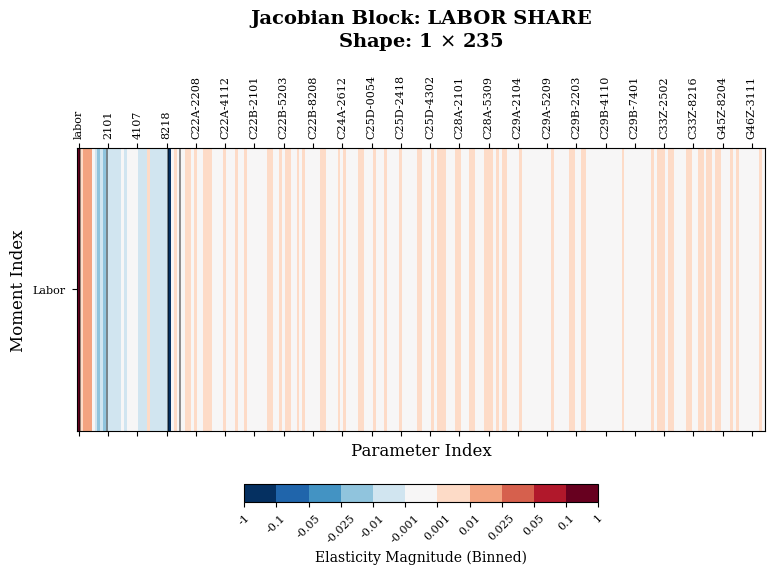

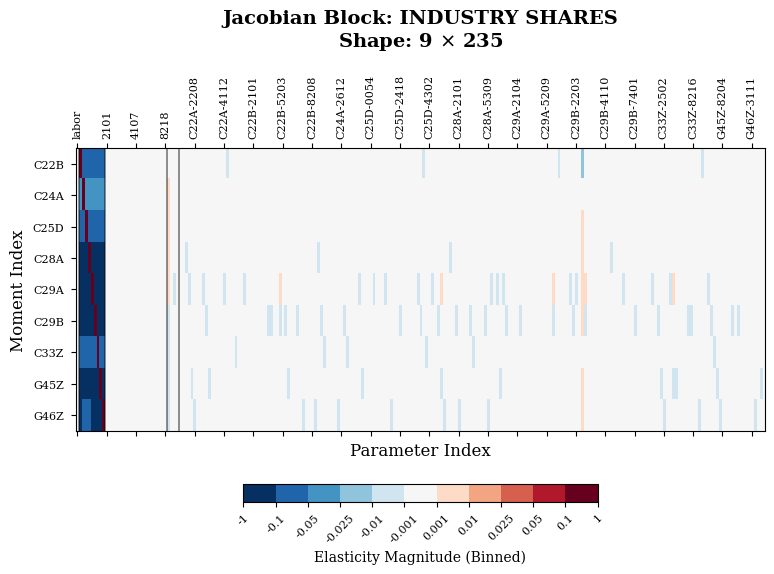

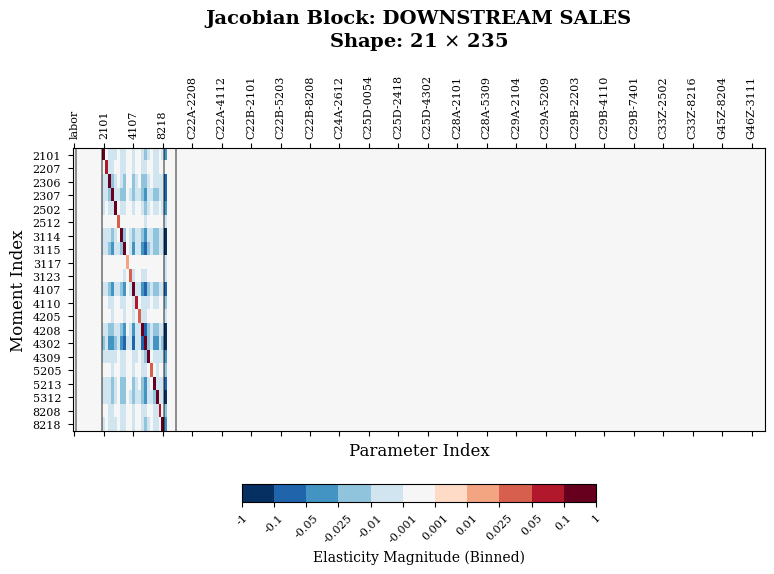

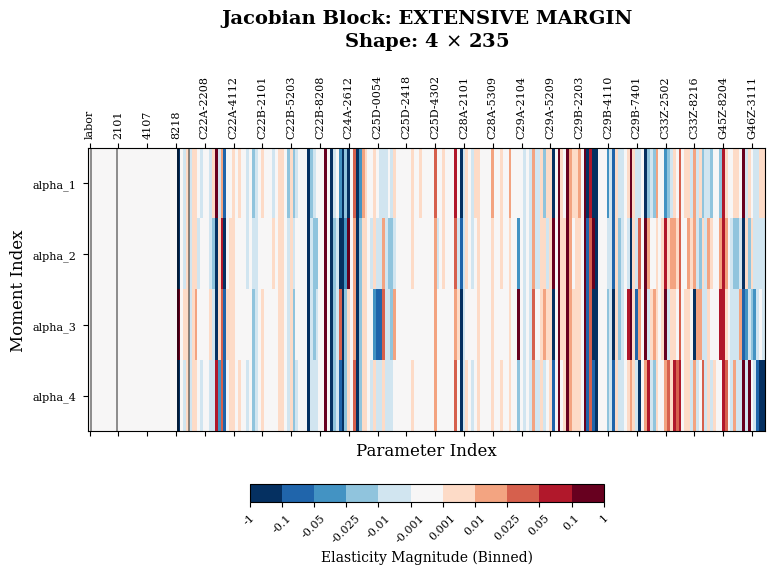

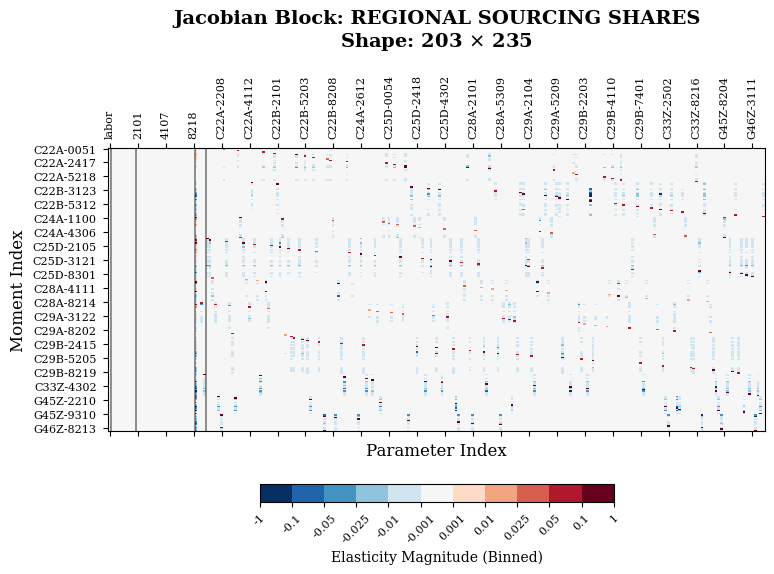

In [47]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm, ListedColormap


y_ticks_map = {

    "Extensive margin":["alpha_1","alpha_2","alpha_3","alpha_4"] if n_coef == 4 else ['alpha'],
    "Labor share":['Labor'],
    "Industry shares":[x for x in sector_names.values()][1:],
    "Downstream sales":X_dr.query('downstream_region').ze2010.to_list()[1:],
    "Regional sourcing shares":df_gamma.query('~reference').params.to_list()
}
# --- 1. Prepare Data ---
block_sizes = [n_labor, n_industry, n_pi_r, n_reg, n_gamma]
block_names = ["Labor share", "Industry shares", "Downstream sales", "Extensive margin", "Regional sourcing shares"]
block_edges = np.cumsum([0] + block_sizes)
split_indices = np.cumsum(block_sizes)[:-1]
J_blocks_list = np.split(J, split_indices)

# --- 2. SETUP BINNED COLORMAP ---
# Your specific thresholds
# We add -inf and inf to ensure values outside the range are still colored
boundaries = [-1, -0.1, -0.05, -0.025, -0.01, -0.001, 0.001, 0.01, 0.025, 0.05, 0.1, 1]

# Create a discrete colormap. 
# We take the 'RdBu_r' map and sample colors at the midpoints of your bins
# to ensure we get a good transition from Red -> White -> Blue.
n_bins = len(boundaries) - 1
cmap_base = plt.get_cmap('RdBu_r')
# We sample colors from the continuous map to create a discrete one
colors = cmap_base(np.linspace(0, 1, n_bins))
binned_cmap = ListedColormap(colors)

# BoundaryNorm maps the data into the indices of the colormap
norm = BoundaryNorm(boundaries, n_bins)

# --- 3. LOOP AND PLOT ---
for i in range(len(block_names)):
    name = block_names[i]
    data = J_blocks_list[i]
    
    fig, ax = plt.subplots(figsize=(8, 6))
    # Alternate subplot background shading
    
    # --- PLOTTING ---
    # Use the new binned_cmap and BoundaryNorm
    im = ax.matshow(data, cmap=binned_cmap, norm=norm, aspect='auto')
    
    # Add the horizontal colorbar
    # We use the boundaries as ticks so the user sees where bins change
    cbar = fig.colorbar(im, ax=ax, orientation='horizontal', fraction=0.05, pad=0.15, ticks=boundaries)
    
    # Format labels to be clean
    cbar.ax.set_xticklabels([f'{t:g}' for t in boundaries], fontsize=8, rotation=45)
    cbar.set_label('Elasticity Magnitude (Binned)', fontsize=10)

    # --- FORMATTING ---
    ax.set_title(f"Jacobian Block: {name.upper()}\nShape: {data.shape[0]} $\\times$ {data.shape[1]}", 
                 fontsize=14, fontweight='bold', pad=20)
    ax.set_xlabel("Parameter Index", fontsize=12)
    ax.set_ylabel("Moment Index", fontsize=12)
    
    # X-axis tick adjustment

    # --- X-AXIS TICK ADJUSTMENT ---
    # 1. Define which tick positions we want (e.g., every 10th index)
    tick_positions = np.arange(data.shape[1])[::10]
    
    # 2. Define the labels for those specific positions
    # Note: ensure 'df.label' is a list/array that matches the full length of parameters
    tick_labels = df.label.values[tick_positions]  

    # 3. Apply ticks and labels
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels, rotation=90, fontsize=8) 
    
    # --- Y-AXIS TICK LOGIC ---
    labels = y_ticks_map.get(name)

    if labels is not None:
        # Determine positions and labels based on the block type
        labels = np.array(labels)
        if name == "Regional sourcing shares":
            # Sampling: 1 out of every 10
            tick_positions = np.arange(len(labels))[::10]
            tick_labels = labels[tick_positions]
        else:
            # For other blocks, we show all labels 
            # (Or you can add [::5] if they are still too crowded)
            tick_positions = np.arange(len(labels))
            tick_labels = labels

        # Apply the ticks
        ax.set_yticks(tick_positions)
        
        # Apply labels with alignment
        # We use rotation=0 for Y-axis labels for better readability
        ax.set_yticklabels(tick_labels, fontsize=8)
        
        # Ensure labels are aligned to the right of the axis
        ax.yaxis.set_tick_params(pad=5) 

    else:
        # If labels is None (like for 'labor'), we can just hide the labels 
        # or show numbers. Usually, hiding is cleaner for single-row blocks.
        ax.set_yticklabels([])

    
    # --- BLOCK SEPARATORS ---
    for edge in block_edges[1:-1]:

        ax.axvline(
            edge - 0.5,
            color='black',
            linewidth=1.2,
            alpha=0.5
        )
    plt.tight_layout()
    plt.show()

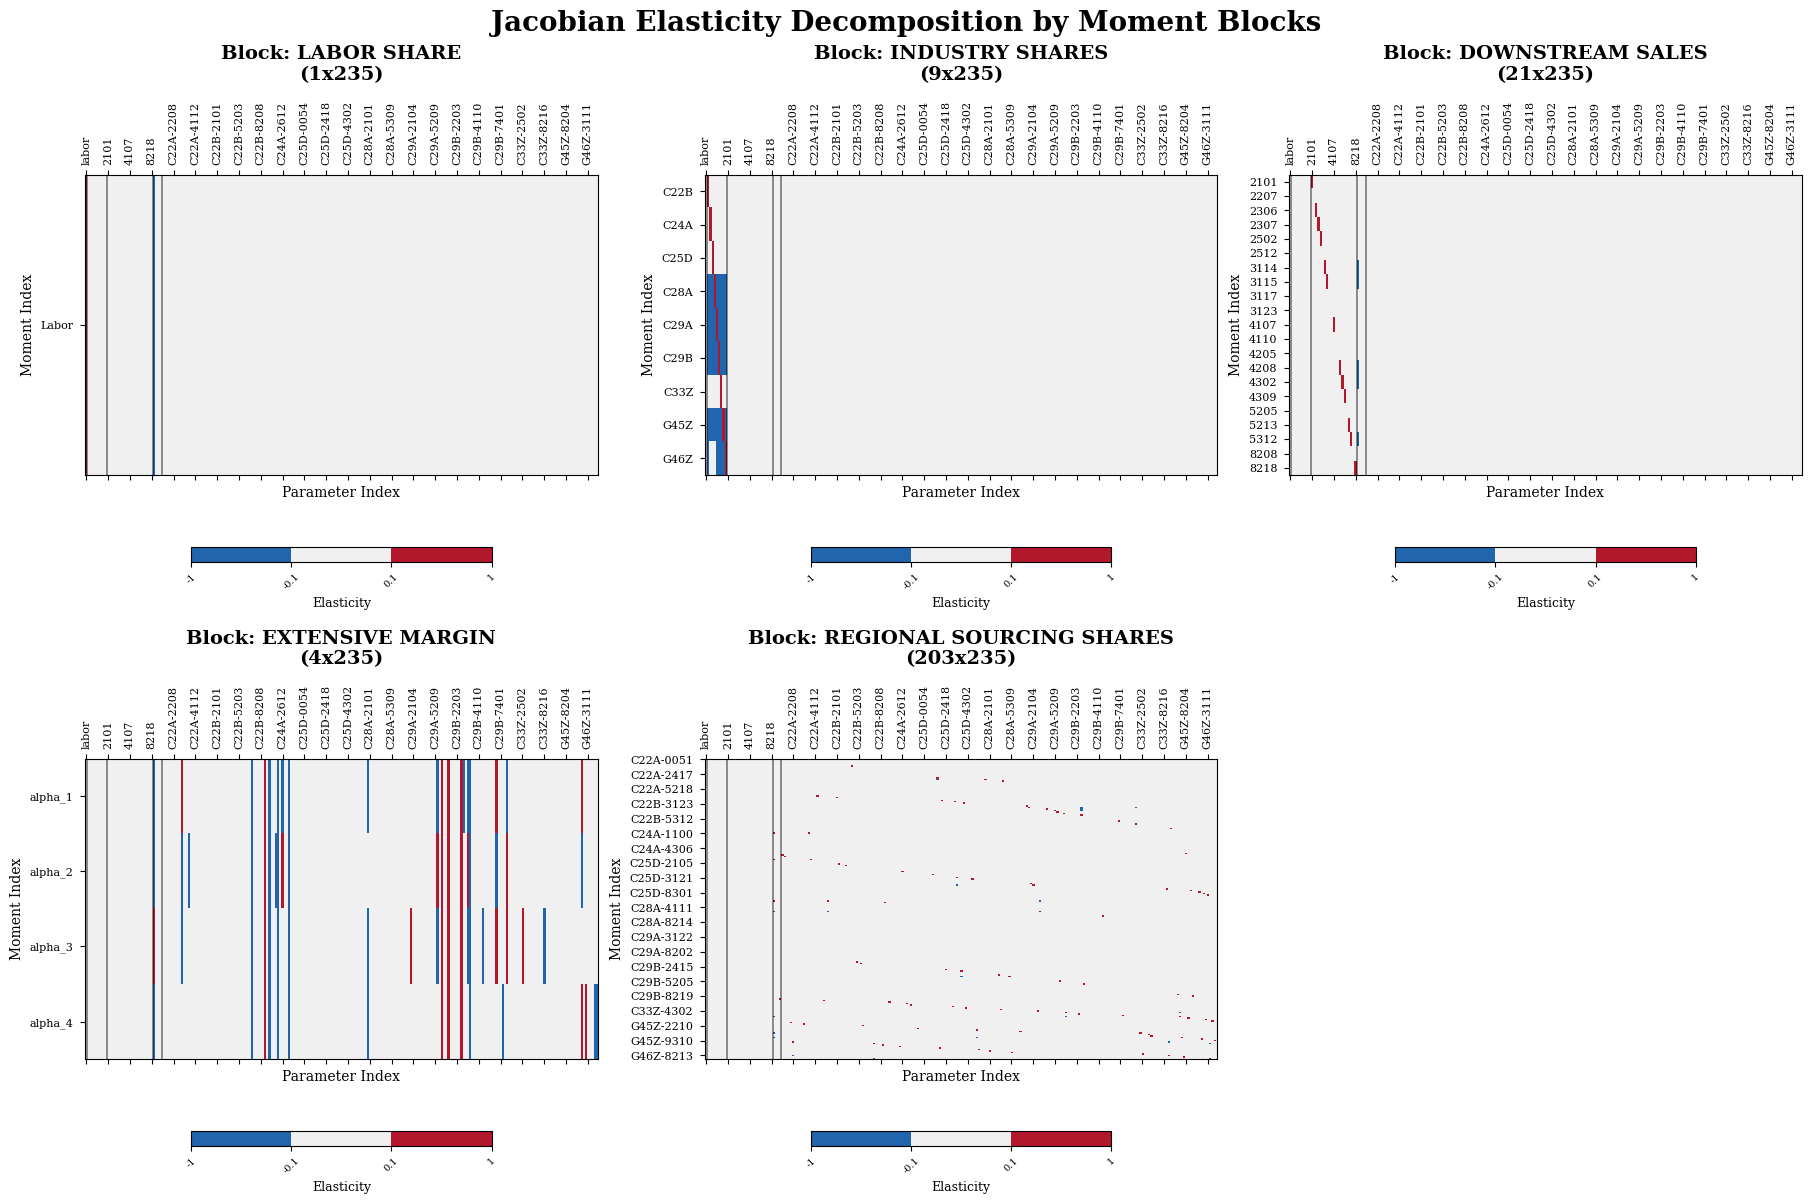

In [46]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm, ListedColormap


# --- 2. SETUP BINNED COLORMAP ---
boundaries = [-1, -0.1, -0.05, -0.025, -0.01, -0.001, 0.001, 0.01, 0.025, 0.05, 0.1, 1]
n_bins = len(boundaries) - 1
cmap_base = plt.get_cmap('RdBu_r')
colors = cmap_base(np.linspace(0, 1, n_bins))
binned_cmap = ListedColormap(colors)
norm = BoundaryNorm(boundaries, n_bins)

# --- 2. SETUP BINNED COLORMAP (HIVar_sandwichHLIVar_sandwichHTING EXTREMES) ---

# We define boundaries such that the middle range [-0.1, 0.1] is one single bin
# The bins will be: [-1, -0.1] (Red/Blue), [-0.1, 0.1] (Gray), [0.1, 1] (Red/Blue)
boundaries = [-1, -0.1, 0.1, 1]
n_bins = len(boundaries) - 1

# Create a custom color list:
# Bin 0: [-1 to -0.1] -> Dark Red
# Bin 1: [-0.1 to 0.1] -> Light Gray (The "Neutral" zone)
# Bin 2: [0.1 to 1] -> Dark Blue
colors = ['#2166ac', '#f0f0f0','#b2182b'] 

binned_cmap = ListedColormap(colors)
norm = BoundaryNorm(boundaries, n_bins)

# --- 3. SETUP SUBPLOT GRID ---
# Using 2 rows and 3 columns to accommodate 5 blocks
fig, axes = plt.subplots(2, 3, figsize=(18, 12), constrained_layout=True)
axes = axes.flatten() # Convert 2D grid to 1D list for easy looping

# --- 4. LOOP AND PLOT ---
for i in range(len(block_names)):
    name = block_names[i]
    data = J_blocks_list[i]
    ax = axes[i]
    
    # --- BLOCK SEPARATORS ---
    for edge in block_edges[1:-1]:

        ax.axvline(
            edge - 0.5,
            color='black',
            linewidth=1.2,
            alpha=0.5
        )
    # --- PLOTTING ---
    im = ax.matshow(data, cmap=binned_cmap, norm=norm, aspect='auto')
    
    # --- INDIVIDUAL COLORBAR PER SUBPLOT ---
    # We attach it to the current 'ax'
    cbar = fig.colorbar(im, ax=ax, orientation='horizontal', fraction=0.05, pad=0.15, ticks=boundaries)
    cbar.ax.set_xticklabels([f'{t:g}' for t in boundaries], fontsize=7, rotation=45)
    cbar.set_label('Elasticity', fontsize=9)

    # --- FORMATTING ---
    ax.set_title(f"Block: {name.upper()}\n({data.shape[0]}x{data.shape[1]})", 
                 fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel("Parameter Index", fontsize=10)
    ax.set_ylabel("Moment Index", fontsize=10)
    
    # --- X-AXIS TICK ADJUSTMENT ---
    # Get positions and labels from df.label
    x_tick_pos = np.arange(data.shape[1])[::10]
    x_tick_labels = df.label.values[x_tick_pos] 

    ax.set_xticks(x_tick_pos)
    ax.set_xticklabels(x_tick_labels, rotation=90, fontsize=8) 
    
    # --- Y-AXIS TICK LOGIC ---
    labels_raw = y_ticks_map.get(name)

    if labels_raw is not None:
        labels = np.array(labels_raw)
        if name == "Regional sourcing shares":
            # Sampling: 1 out of every 10
            y_tick_pos = np.arange(len(labels))[::10]
            y_tick_labels = labels[y_tick_pos]
        else:
            y_tick_pos = np.arange(len(labels))
            y_tick_labels = labels

        ax.set_yticks(y_tick_pos)
        ax.set_yticklabels(y_tick_labels, fontsize=8)
        ax.yaxis.set_tick_params(pad=5) 
    else:
        ax.set_yticks([]) # Hide ticks for blocks like 'labor'

# --- 5. CLEANUP UNUSED SUBPLOTS ---
# Since we have 6 subplots (2x3) but only 5 blocks, hide the 6th one
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle("Jacobian Elasticity Decomposition by Moment Blocks", fontsize=20, fontweight='bold')
plt.show()

In [39]:
J_blocks_list[-1][3:,block_edges[-2]:].shape

(200, 200)

In [24]:
data[block_edges[-2]:,block_edges[-2]:]

array([[-1.26057959e-09, -5.39389077e-09, -2.17459311e-09, ...,
         1.61892259e-09,  9.73979289e-10, -3.86678928e-03],
       [ 1.34525377e-11, -4.19138536e-10, -2.95154600e-11, ...,
         3.05655630e-11,  2.85567589e-11, -8.88649275e-04],
       [-1.22154412e-09, -4.85379002e-09, -2.33563841e-09, ...,
         9.59966748e-10,  6.99248594e-10, -3.55370565e-03],
       ...,
       [-1.17034048e-08, -1.59514685e-08, -8.22292182e-09, ...,
         2.61347218e-09,  5.01295154e-09,  1.01924897e-09],
       [-9.99013273e-09, -1.24339678e-08, -5.47667295e-09, ...,
         1.88327900e-09,  2.51908299e-08,  7.97477709e-10],
       [-1.29979685e-08, -1.57366932e-08, -6.88503023e-09, ...,
         3.57676723e-09,  2.79192037e-08,  9.48766534e-10]],
      shape=(168, 200))

### Variance-Covariance matrix

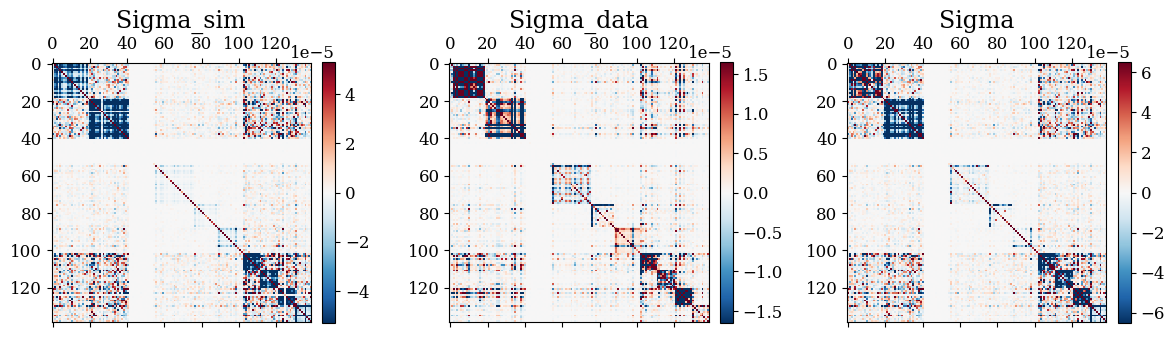

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

Sigma_sim = np.load(f"../reporting_{industry}/step2/Sigma_sim.npy")
Sigma_data = np.load(f"../reporting_{industry}/step2/Sigma_data.npy")

fig, axes = plt.subplots(1, 3, figsize=(12, 5))

# --- Sigma_sim ---
v_sim = np.percentile(np.abs(Sigma_sim), 95)
norm_sim = TwoSlopeNorm(vmin=-v_sim, vcenter=0, vmax=v_sim)

im0 = axes[0].matshow(Sigma_sim, cmap='RdBu_r', norm=norm_sim)
axes[0].set_title("Sigma_sim")
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

# --- Sigma_data ---
v_data = np.percentile(np.abs(Sigma_data), 95)
norm_data = TwoSlopeNorm(vmin=-v_data, vcenter=0, vmax=v_data)

im1 = axes[1].matshow(Sigma_data, cmap='RdBu_r', norm=norm_data)
axes[1].set_title("Sigma_data")
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

# --- Sigma ---
K  = 10000
Sigma = Sigma_data + (1 + 1/K)*Sigma_sim
v_data = np.percentile(np.abs(Sigma), 95)
norm_data = TwoSlopeNorm(vmin=-v_data, vcenter=0, vmax=v_data)

im1 = axes[2].matshow(Sigma, cmap='RdBu_r', norm=norm_data)
axes[2].set_title("Sigma")
fig.colorbar(im1, ax=axes[2], fraction=0.046, pad=0.04)



plt.tight_layout()
plt.show()

In [ ]:
np.trace(Sigma_sim)/np.trace(Sigma_data)

In [ ]:
Precision = np.linalg.inv(Sigma)
plt.hist(np.ndarray.flatten(Precision))

# On veut savoir quels sont les valeurs importantes. 

### Inference matrix

**(G'WG) (GWG)**: the weighted Jacobian cross-product matrix used in SMM/GMM, forming the core “information” term for efficient parameter variance via ((G'WG)^{-1}). G is J, the Jacobian. 


In [ ]:
import numpy as np

Omega_sim = np.load(f"../reporting_{industry}/step2/Sigma_sim.npy")
Omega_data = np.load(f"../reporting_{industry}/step2/Sigma_data.npy")
Omega = (Omega_sim + Omega_data)


# gamma rows first (to match Sigma_beta_gamma.npy ordering: γ block then β block)
G = np.vstack([
    J[(n_labor + n_industry + n_pi_r):, :]
])[:, df[df.label.str.contains('beta|-')].coord.values]

W = np.linalg.inv(Omega)
Var_eff = np.linalg.inv(G.T @ W @ G)

middle = G.T @ W @ Omega @ W @ G

Var_sandwich = Var_eff @ middle @ Var_eff
Var_sandwich = (Var_sandwich + Var_sandwich.T) / 2  # enforce symmetry

# ---- inference quantities ----
se_eff = np.sqrt(np.maximum(np.diag(Var_eff), 0.0))
se_sw  = np.sqrt(np.maximum(np.diag(Var_sandwich), 0.0))

theta_active = best_params[df[df.label.str.contains('beta|-')].coord.values,-1]

t_stats = theta_active / se_eff

ci_95 = np.column_stack([
    theta_active - 1.96 * se_eff,
    theta_active + 1.96 * se_eff
])
se_eff

In [ ]:

U, S_vals, Vt = np.linalg.svd(Var_sandwich, full_matrices=True)
n_null = np.sum(S_vals < 1e-8 * S_vals[0])
print(f"Numerical nullity: {n_null}")
print(f"Singular values (bottom 10): {S_vals[-10:]}")

# Examine each null vector
for i in range(1, n_null + 1):
    v = Vt[-i, :]  # null vector in parameter space
    # Split into beta and T components
    v_beta = v[:n_reg]
    v_T = v[n_reg:]
    
    print(f"\nNull vector {i}:")
    print(f"  ||v_beta||/||v|| = {np.linalg.norm(v_beta)/np.linalg.norm(v):.4f}")
    print(f"  ||v_T||/||v||    = {np.linalg.norm(v_T)/np.linalg.norm(v):.4f}")
    
    # Which T parameters dominate?
    top_T = np.argsort(np.abs(v_T))[-5:]
    for idx in top_T:
        # Map idx back to (s, r) — you'll need the T_MASK mapping
        print(f"  T param {idx}: weight {v_T[idx]:.4f}")


col_norms = np.linalg.norm(G, axis=0)
dead_params = np.where(col_norms < 1e-6 * np.max(col_norms))[0]
print(f"Near-zero columns: {len(dead_params)}")
# Map these back to parameter names

In [ ]:
# reg_coef rows in G: these are the first N_beta rows 
# (you stacked reg_coef first, then gamma — or the reverse; 
#  check your ordering)
# β columns in G: first N_beta columns (since you selected beta then T)

G_reg_beta = G[:n_reg, :n_reg]  # or adjust indices to match your stacking

print("G_reg_beta:")
print(G_reg_beta)
print(f"Rank: {np.linalg.matrix_rank(G_reg_beta, tol=1e-8)}")
print(f"Singular values: {np.linalg.svd(G_reg_beta, compute_uv=False)}")
print(f"Condition number: {np.linalg.cond(G_reg_beta)}")

In [ ]:
G_reg_T = G[:n_reg, n_reg:]  # reg_coef rows, T columns

# Can G_reg_T replicate the columns of G_reg_beta?
# For each beta column, find best T approximation
for b in range(n_reg):
    target = G_reg_beta[:, b]
    # Least-squares: find w such that G_reg_T @ w ≈ target
    w, residual, _, _ = np.linalg.lstsq(G_reg_T, target, rcond=None)
    approx = G_reg_T @ w
    rel_error = np.linalg.norm(target - approx) / np.linalg.norm(target)
    print(f"β_{b+1}: ||residual||/||target|| = {rel_error:.6f}")

In [ ]:

U, S_vals, Vt = np.linalg.svd(G, full_matrices=True)
null_vec_1 = Vt[-1, :]  # last row of Vt = smallest singular value
null_vec_2 = Vt[-2, :]
null_vec_3 = Vt[-3, :]

_, _, Vt_reg = np.linalg.svd(G_reg_beta)
weakest_beta_direction = Vt_reg[-1, :]  # right singular vector for sv=0.0035
print("Weakest β direction:", weakest_beta_direction)

# Compare to null vectors 1 and 3 (β components only)
for i, nv in enumerate([null_vec_1[:N_beta], null_vec_3[:n_reg]]):
    nv_normalized = nv / np.linalg.norm(nv)
    cosine = np.abs(nv_normalized @ weakest_beta_direction)
    print(f"Cosine similarity with null vector {i+1} β-part: {cosine:.4f}")

In [ ]:
# The 3 null vectors' beta components
V_null_beta = np.vstack([null_vec_1[:n_reg], 
                          null_vec_2[:N_beta], 
                          null_vec_3[:n_reg]])  # (3, 4)

# The identified beta direction: orthogonal complement
U_nb, S_nb, Vt_nb = np.linalg.svd(V_null_beta)
identified_beta = Vt_nb[-1, :]  # last right singular vector
print("Identified β direction:", identified_beta)

# For any candidate single-β direction, check alignment
candidate = np.array([1, 2, 3, 4], dtype=float)  # e.g., log-distance weights
candidate /= np.linalg.norm(candidate)
projection = np.abs(candidate @ identified_beta)
print(f"Projection onto identified direction: {projection:.4f}")
# Close to 0 = bad (weakly identified). Close to 1 = good.

In [ ]:
X_dr.query('downstream_region')

In [ ]:
pi_r_reference = X_dr.query('downstream_region')
pi_r_reference = pi_r_reference[pi_r_reference.X_dr != pi_r_reference.X_dr.max()]
pi_r_reference

In [46]:
industry = "aero"
print("The industry is: ", industry)
data = load_industry_data(industry)
globals().update(data) 

sector_names = filter_N_upstream_df[['A129']].drop_duplicates().sort_values(by = "A129").reset_index()
sector_names.index +=1 
sector_names = sector_names['A129'].to_dict()

ze_names = filter_N_upstream_df[['ze2010']].drop_duplicates().sort_values(by = "ze2010").reset_index()
ze_names.index +=1 
ze_names = ze_names['ze2010'].to_dict()


# La Jacobienne est définie sur tous les paramètres sauf ceux de référence.
# De même pour les momentµs.  
J = np.load(f"../reporting_{industry}/step3/jacobian_all_step3.npy")
J_e = np.load(f"../reporting_{industry}/step3/jacobian_all_step3_elasticity.npy")


n_labor    = 1 
n_industry = empirical_moments_dict['agg_industry_share'].shape[0] - 1
n_gamma    = np.count_nonzero(np.ndarray.flatten(empirical_moments_dict['emp_gamma_ls'])) - (n_industry + 1) 
n_reg      = n_coef
n_pi_r     = empirical_moments_dict['emp_pi_r'].shape[0] - 1


gamma_matrix = empirical_moments_dict['emp_gamma_ls']
index_labels = [sector_names[i] for i in range(1, len(sector_names) + 1)]
column_labels = [ze_names[i] for i in range(1, len(ze_names) + 1)]

# 2. Create the DataFrame
df_gamma = pd.DataFrame(
    gamma_matrix, 
    index=index_labels, 
    columns=column_labels
)

# Display result
df_gamma = df_gamma.stack().reset_index()
df_gamma = df_gamma.reset_index()
df_gamma.columns = ['coord','A129',"ze2010","gamma_ls"]
df_gamma.sort_values(by = ['ze2010','A129'],inplace = True)
df_gamma = df_gamma.query('gamma_ls != 0')
df_gamma['new_coord'] = df_gamma.coord.rank().astype(int)+3
df_gamma['params'] = df_gamma['A129'] + "-" + df_gamma['ze2010']
df_gamma['reference'] = df_gamma.gamma_ls == df_gamma.groupby('A129').gamma_ls.transform('max')

pi_r_reference = X_dr.query('downstream_region')
pi_r_reference['reference'] = pi_r_reference.X_dr == pi_r_reference.X_dr.max()
labor = pd.DataFrame({"params":['labor'],'reference':[False]})
industry_df = pd.DataFrame({"params":[x for x in sector_names.values()],'reference':[True]+[False for i in range(9)]})
reg_coef_df = pd.DataFrame({"params":["reg_coef"],'reference':[False]})


df = pd.concat([labor,industry_df,pi_r_reference,reg_coef_df,df_gamma[['params','reference']]])
df = df.reset_index(drop = True).reset_index()
df['coord'] = df['index'].rank().astype(int)-1
df['label'] = df.params
df = df[['label','coord','reference']]

T_sr = df.iloc[(n_labor + n_industry + n_pi_r + n_reg):,:]
T_sr = T_sr.reset_index(drop = True).reset_index().drop("coord",axis = 1).rename(columns  = {"index":'coord'})
T_sr = T_sr.merge(df_gamma[['params','gamma_ls','A129','ze2010']],left_on = "label",right_on = "params").drop("params",axis = 1)
T_sr['top_T'] = 0
import numpy as np

Omega_sim = np.load(f"../reporting_{industry}/step2/Sigma_sim.npy")
Omega_data = np.load(f"../reporting_{industry}/step2/Sigma_data.npy")
W = np.load(f"../reporting_{industry}/step2/W_step3.npy")
theta_hat_2 = np.load(f"../reporting_{industry}/step3/theta_hat_2.npy")
Omega = (Omega_sim + Omega_data)


# gamma rows first (to match Sigma_beta_gamma.npy ordering: γ block then β block)
G = J[-57:, -57:]
G

The industry is:  aero


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


array([[ 2.50447785e-10,  5.57087508e-09, -1.16621110e-08, ...,
         3.92543451e-10,  3.68803071e-09,  2.53100796e-09],
       [ 3.10025177e-10,  8.53915847e-09, -1.84400679e-08, ...,
         1.10045661e-09,  6.90597731e-09,  5.48312585e-09],
       [ 1.86263782e-10,  2.13521533e-09, -8.57272118e-09, ...,
         5.40972561e-10,  3.11465135e-09,  1.67505111e-09],
       ...,
       [ 8.68250571e-11,  8.73113440e-10,  9.40544553e-10, ...,
        -1.37950384e-03,  1.86408821e-09,  7.21464738e-10],
       [ 2.62977881e-10,  3.48646046e-09, -2.55088763e-09, ...,
        -1.63975586e-03,  3.81900352e-09,  1.41164008e-09],
       [ 1.92642344e-09,  3.04641674e-08, -4.72585808e-08, ...,
         2.44717152e-01,  1.54489381e-08,  6.38618084e-09]],
      shape=(57, 57))

In [47]:
def remove_lr(mat,coord = None):
    if coord :
        mat_reduced = np.delete(mat, coord, axis=0)
        mat_reduced = np.delete(mat_reduced, coord, axis=1)
        return mat_reduced
    else:
        return mat

In [48]:
import numpy as np


def remove_coord(mat, coord=None):
    """
    Remove row/column `coord` from a square matrix.

    Parameters
    ----------
    mat : ndarray
        Square matrix.
    coord : int or None
        Coordinate to remove. If None, returns mat unchanged.
    """
    if coord is None:
        return mat

    mat = np.delete(mat, coord, axis=0)
    mat = np.delete(mat, coord, axis=1)
    return mat


def get_coord(df, label=None, offset=12):
    """
    Convert a label into a coordinate.

    Parameters
    ----------
    label : str or None
        Label of the direction to remove.
    offset : int
        Offset between dataframe coordinates and matrix coordinates.
    """
    if label is None:
        return None

    return df.loc[df.label == label, "coord"].iloc[0] - offset

In [49]:
# Choose the direction to remove
removed_label = None      # or None

coord = get_coord(df, removed_label)

G = remove_coord(J, coord)[-(n_reg + n_gamma - (coord is not None)):,
                           -(n_reg + n_gamma - (coord is not None)):]

W_ = remove_coord(W, coord)
Omega_ = remove_coord(Omega, coord)

GtWG = G.T @ W_ @ G
GtWG_inv = np.linalg.inv(GtWG)

Var_sandwich = (
    GtWG_inv
    @ (G.T @ W_ @ Omega_ @ W_ @ G)
    @ GtWG_inv
)

se = np.sqrt(np.diag(Var_sandwich))

mask = (
    df.label.str.contains("reg_coef|-")
    & (~df.reference)
)

if removed_label is not None:
    mask &= (df.label != removed_label)

reg_df = df.loc[mask]

theta = theta_hat_2[reg_df.coord]

ci_lo = theta - 1.96 * se
ci_hi = theta + 1.96 * se

print(list(zip(ci_lo, ci_hi)))

eigval, eigvec = np.linalg.eig(GtWG)
eigvec = eigvec[:, np.argsort(eigval)]

tmp = reg_df.copy()
i = 0
tmp["eigvec_coef"] = eigvec[:, i]
tmp["eigvec_load"] = eigvec[:, i]

tmp["gamma_ls"] = 1.0
tmp.iloc[1:, tmp.columns.get_loc('gamma_ls')] = df_gamma.query('~reference').gamma_ls.values.astype(float)
tmp["A129"] = tmp.label.str[:4]
tmp["gamma_ls_norm"] = tmp["gamma_ls"]/tmp.groupby("A129")["gamma_ls"].transform("sum")

print(tmp.sort_values("eigvec_load").tail(20))

def identification_diagnostics(
    removed_label=None,
    df=df,
    J=J,
    W=W,
    Omega=Omega,
    theta_hat=theta_hat_2,
    offset=12,
):
    coord = get_coord(df, removed_label, offset)

    G = remove_coord(J, coord)
    k = 1 if coord is not None else 0
    G = G[-(n_reg + n_gamma - k):, -(n_reg + n_gamma - k):]

    W_ = remove_coord(W, coord)
    Omega_ = remove_coord(Omega, coord)

    GtWG = G.T @ W_ @ G
    GtWG_inv = np.linalg.inv(GtWG)

    var = (
        GtWG_inv
        @ (G.T @ W_ @ Omega_ @ W_ @ G)
        @ GtWG_inv
    )

    se = np.sqrt(np.diag(var))

    mask = (
        df.label.str.contains("reg_coef|-")
        & (~df.reference)
    )

    if removed_label is not None:
        mask &= (df.label != removed_label)

    reg_df = df.loc[mask]

    return {
        "se": se,
        "ci_lo": theta_hat[reg_df.coord] - 1.96 * se,
        "ci_hi": theta_hat[reg_df.coord] + 1.96 * se,
        "GtWG": GtWG,
        "reg_df": reg_df,
    }

#res = identification_diagnostics("C26E-0061")
res = identification_diagnostics(None)  # no removal

[(np.float64(-0.19571605539339798), np.float64(0.19848565987374617)), (np.float64(-0.40763529400271215), np.float64(0.4363504033322303)), (np.float64(-0.18112054617751103), np.float64(0.3283644790135587)), (np.float64(-1.047511668302831), np.float64(2.4195572279781357)), (np.float64(-0.24374293245206002), np.float64(1.2805613363173958)), (np.float64(-0.8651396169458831), np.float64(1.834924310764371)), (np.float64(-1.7716548325907842), np.float64(3.4622696041938554)), (np.float64(-0.2858303739656848), np.float64(0.4047967827188653)), (np.float64(-1.1490311378283582), np.float64(2.68369873164536)), (np.float64(-0.2310196464182478), np.float64(0.733913066197647)), (np.float64(-0.5943690578128846), np.float64(2.200699866017583)), (np.float64(0.42877786697505993), np.float64(1.4760226671252583)), (np.float64(-0.34146219797473515), np.float64(0.8023168554059528)), (np.float64(-0.4419428107724386), np.float64(0.8625177706200271)), (np.float64(-1.4252831234175474), np.float64(3.52873507400393

In [36]:
np.sort(eigval)

array([9.41212463e-02, 1.30626199e-01, 6.15220159e-01, 1.06516441e+00,
       1.10531014e+00, 1.20491661e+00, 1.33626801e+00, 1.36390099e+00,
       1.44248962e+00, 1.45986280e+00, 1.52879010e+00, 1.55503990e+00,
       1.81565195e+00, 1.98467540e+00, 2.02629857e+00, 2.16312484e+00,
       2.23621702e+00, 2.32251768e+00, 2.35205123e+00, 2.53454610e+00,
       2.62413806e+00, 2.67569948e+00, 2.71578819e+00, 2.78643742e+00,
       2.80997172e+00, 2.93866043e+00, 3.01898531e+00, 3.23810596e+00,
       3.32012277e+00, 3.33363844e+00, 3.49790549e+00, 3.53610642e+00,
       3.71284561e+00, 3.83797039e+00, 3.93911118e+00, 4.43611022e+00,
       4.59493670e+00, 4.63211866e+00, 4.84782944e+00, 4.94302817e+00,
       5.02332569e+00, 5.10985021e+00, 5.24708004e+00, 5.59314114e+00,
       5.83641898e+00, 6.24055466e+00, 6.32381044e+00, 6.96998063e+00,
       7.19943547e+00, 7.39038189e+00, 7.66095969e+00, 8.03408703e+00,
       8.12393988e+00, 8.24829809e+00, 8.38141171e+00, 8.76515580e+00,
      

In [28]:
np.load(os.path.join(input_folder,"domestic_share.npy"))

array([0.620559  , 1.        , 0.00501193, 0.19088555, 0.17652106,
       0.27310687, 0.92690861, 0.9124189 , 0.93703045, 0.7935809 ])

In [26]:
tmp.sort_values("eigvec_load")

,label,coord,reference,eigvec_coef,eigvec_load,gamma_ls,A129,gamma_ls_norm
90,C22B-5203,90,False,-0.529270,-0.529270,0.046365,C22B,0.099404
130,C25D-7301,130,False,-0.278410,-0.278410,0.048416,C25D,0.082878
133,C25D-7309,133,False,-0.240654,-0.240654,0.064543,C25D,0.110484
36,C25D-0060,36,False,-0.175191,-0.175191,0.038348,C25D,0.065644
161,C25D-8310,161,False,-0.171356,-0.171356,0.075152,C25D,0.128644
...,...,...,...,...,...,...,...,...
52,C30C-1100,52,False,0.004394,0.004394,0.028420,C30C,0.221750
77,C25D-2416,77,False,0.008738,0.008738,0.027058,C25D,0.046318
56,M71Z-1100,56,False,0.017560,0.017560,0.251574,M71Z,0.633225
41,C27B-0061,41,False,0.055456,0.055456,0.026642,C27B,0.218568


In [206]:
U, S_vals, Vt = np.linalg.svd(Var_sandwich, full_matrices=True)
n_null = np.sum(S_vals < 1e-8 * S_vals[0])
print(f"Numerical nullity: {n_null}")
print(f"Singular values (bottom 10): {S_vals[-10:]}")

# Examine each null vector
for i in range(1, n_null + 1):
    v = Vt[-i, :]  # null vector in parameter space
    # Split into beta and T components
    v_beta = v[:n_reg]
    v_T = v[n_reg:]
    
    print(f"\nNull vector {i}:")
    print(f"  ||v_beta||/||v|| = {np.linalg.norm(v_beta)/np.linalg.norm(v):.4f}")
    print(f"  ||v_T||/||v||    = {np.linalg.norm(v_T)/np.linalg.norm(v):.4f}")
    
    # Which T parameters dominate?
    top_T = np.argsort(np.abs(v_T))[-10:]
    for idx in top_T:
        # Map idx back to (s, r) — you'll need the T_MASK mapping
        print(f"  T param {idx}: weight {v_T[idx]:.4f}")
        T_sr.loc[T_sr.coord.isin(top_T-4),"top_T"] +=1


col_norms = np.linalg.norm(Var_sandwich, axis=0)
dead_params = np.where(col_norms < 1e-6 * np.max(col_norms))[0]
print(f"Near-zero columns: {len(dead_params)}")
# Map these back to parameter names

# reg_coef rows in G: these are the first n_reg rows 
# (you stacked reg_coef first, then gamma — or the reverse; 
#  check your ordering)
# β columns in G: first n_reg columns (since you selected beta then T)

G_reg_beta = Var_sandwich[:n_reg, :n_reg]  # or adjust indices to match your stacking

print("G_reg_beta:")
print(G_reg_beta)
print(f"Rank: {np.linalg.matrix_rank(G_reg_beta, tol=1e-8)}")
print(f"Singular values: {np.linalg.svd(G_reg_beta, compute_uv=False)}")
print(f"Condition number: {np.linalg.cond(G_reg_beta)}")

G_reg_T = G[:n_reg, n_reg:]  # reg_coef rows, T columns

# Can G_reg_T replicate the columns of G_reg_beta?
# For each beta column, find best T approximation
for b in range(n_reg):
    target = G_reg_beta[:, b]
    # Least-squares: find w such that G_reg_T @ w ≈ target
    w, residual, _, _ = np.linalg.lstsq(G_reg_T, target, rcond=None)
    approx = G_reg_T @ w
    rel_error = np.linalg.norm(target - approx) / np.linalg.norm(target)
    print(f"β_{b+1}: ||residual||/||target|| = {rel_error:.6f}")


U, S_vals, Vt = np.linalg.svd(Var_sandwich, full_matrices=True)
null_vec_1 = Vt[-1, :]  # last row of Vt = smallest singular value
null_vec_2 = Vt[-2, :]
null_vec_3 = Vt[-3, :]

_, _, Vt_reg = np.linalg.svd(G_reg_beta)
weakest_beta_direction = Vt_reg[-1, :]  # right singular vector for sv=0.0035
print("Weakest β direction:", weakest_beta_direction)

# Compare to null vectors 1 and 3 (β components only)
for i, nv in enumerate([null_vec_1[:n_reg], null_vec_3[:n_reg]]):
    nv_normalized = nv / np.linalg.norm(nv)
    cosine = np.abs(nv_normalized @ weakest_beta_direction)
    print(f"Cosine similarity with null vector {i+1} β-part: {cosine:.4f}")

# The 3 null vectors' beta components
V_null_beta = np.vstack([null_vec_1[:n_reg], 
                        null_vec_2[:n_reg], 
                        null_vec_3[:n_reg]])  # (3, 4)

# The identified beta direction: orthogonal complement
U_nb, S_nb, Vt_nb = np.linalg.svd(V_null_beta)
identified_beta = Vt_nb[-1, :]  # last right singular vector
print("Identified β direction:", identified_beta)

# # For any candidate single-β direction, check alignment
# candidate = np.array([1, 2, 3, 4], dtype=float)  # e.g., log-distance weights
# candidate /= np.linalg.norm(candidate)
# projection = np.abs(candidate @ identified_beta)
# print(f"Projection onto identified direction: {projection:.4f}")
# # Close to 0 = bad (weakly identified). Close to 1 = good.
# plt.scatter(T_sr.top_T,T_sr.gamma_ls)
# plt.title(industry)
# plt.show()

Numerical nullity: 0
Singular values (bottom 10): [4.78509833e-02 4.41653196e-02 4.32344576e-02 3.49399491e-02
 3.05284703e-02 2.66975226e-02 2.05017532e-02 1.76637180e-03
 1.44668204e-03 5.41501558e-05]
Near-zero columns: 0
G_reg_beta:
[[0.22250673]]
Rank: 1
Singular values: [0.22250673]
Condition number: 1.0
β_1: ||residual||/||target|| = 0.000000
Weakest β direction: [1.]
Cosine similarity with null vector 1 β-part: 1.0000
Cosine similarity with null vector 2 β-part: 1.0000
Identified β direction: [1.]


In [ ]:

def remove_lr(mat,coord = None):
    if coord :
        mat_reduced = np.delete(mat, coord, axis=0)
        mat_reduced = np.delete(mat_reduced, coord, axis=1)
        return mat_reduced
    else:
        return mat
J = np.load(f"../reporting_{industry}/jacobian_all_step3.npy")
J_e = np.load(f"../reporting_{industry}/jacobian_all_step3_elasticity.npy")


Omega_sim = np.load(f"../reporting_{industry}/step2/Sigma_sim.npy")
Omega_data = np.load(f"../reporting_{industry}/step2/Sigma_data.npy")
W = np.load(f"../reporting_{industry}/step2/W_step3.npy")
Omega = Omega_sim + Omega_data

coord = df.query('label == "C26E-0061"').coord.values[0]-12

G = remove_lr(J,coord)[-(n_reg + n_gamma-1):, -(n_reg + n_gamma-1):]
W_ = remove_lr(W,coord)
GtWG = G.T @ W_ @ G
GtWG_inv = np.linalg.inv(G.T @ W_ @ G)
Var_sandwich = (
    GtWG_inv
    @ (G.T @ W_ @ remove_lr(Omega,coord) @ W_ @ G)
    @ GtWG_inv
)

se = np.sqrt(np.diag(Var_sandwich))

ci_lo = theta_hat_2[df[(df.label.str.contains('reg_coef|-'))&(df.label != "C26E-0061")].query('~reference').coord] - 1.96 * se
ci_hi = theta_hat_2[df[(df.label.str.contains('reg_coef|-'))&(df.label != "C26E-0061")].query('~reference').coord] + 1.96 * se


print([(lo,hi) for lo,hi in zip(ci_lo,ci_hi)])



eigval,eigvec = np.linalg.eig(GtWG)
eigvec = eigvec[:,np.argsort(eigval)]

tmp = df[df.label.str.contains('reg_coef|-')&(df.label != "C26E-0061")].query('~reference')
tmp['eigvec_load'] = np.abs(eigvec[:,0])
tmp['gamma_ls'] = 1.
#tmp.iloc[1:, tmp.columns.get_loc('gamma_ls')] = df_gamma.query('~reference').gamma_ls.values.astype(float)
tmp['A129'] = tmp.label.str[:4]
tmp['gamma_ls'] /= tmp.groupby('A129').gamma_ls.transform("sum")
print(tmp.sort_values(by = 'eigvec_load').tail(20))

[(np.float64(-0.9257883298655827), np.float64(0.9269472941639174)), (np.float64(-0.24000335359094666), np.float64(1.181588266384071)), (np.float64(-0.5173453415949028), np.float64(1.3981264235943416)), (np.float64(-1.1582509319677836), np.float64(1.946164105151234)), (np.float64(-213.04908561082527), np.float64(214.81632665251055)), (np.float64(0.4006510120957404), np.float64(1.1588288996963505)), (np.float64(0.2568818368508561), np.float64(1.7996279927968408)), (np.float64(-0.17339097928124986), np.float64(0.9827776189628992)), (np.float64(-0.16469393358610085), np.float64(1.7832084911837636)), (np.float64(0.04724074889371643), np.float64(1.668988767117602)), (np.float64(-0.34692558869259804), np.float64(1.0304396680876282)), (np.float64(-0.3532897449553769), np.float64(2.062698373378561)), (np.float64(0.499656776558152), np.float64(1.6508712851719065)), (np.float64(-1.3840915324561966), np.float64(1.9619104111865688)), (np.float64(-0.8371502290446121), np.float64(1.8938492264327547))

In [ ]:
for industry in ['aero']:
    print("The industry is: ", industry)
    data = load_industry_data(industry)
    globals().update(data)  


    # La Jacobienne est définie sur tous les paramètres sauf ceux de référence.
    # De même pour les momentµs.  
    J = np.load(f"../reporting_{industry}/step2/jacobian_all.npy")
    J_e = np.load(f"../reporting_{industry}/step2/jacobian_all_elasticity.npy")


    n_labor    = 1 
    n_industry = empirical_moments_dict['agg_industry_share'].shape[0] - 1
    n_gamma    = np.count_nonzero(np.ndarray.flatten(empirical_moments_dict['emp_gamma_ls'])) - (n_industry + 1) 
    n_reg      = n_coef
    n_pi_r     = empirical_moments_dict['emp_pi_r'].shape[0] - 1

    sector_names = filter_N_upstream_df[['A129']].drop_duplicates().sort_values(by = "A129").reset_index()
    sector_names.index +=1 
    sector_names = sector_names['A129'].to_dict()

    ze_names = filter_N_upstream_df[['ze2010']].drop_duplicates().sort_values(by = "ze2010").reset_index()
    ze_names.index +=1 
    ze_names = ze_names['ze2010'].to_dict()

    gamma_matrix = empirical_moments_dict['emp_gamma_ls']
    index_labels = [sector_names[i] for i in range(1, len(sector_names) + 1)]
    column_labels = [ze_names[i] for i in range(1, len(ze_names) + 1)]

    # 2. Create the DataFrame
    df_gamma = pd.DataFrame(
        gamma_matrix, 
        index=index_labels, 
        columns=column_labels
    )

    # Display result
    df_gamma = df_gamma.stack().reset_index()
    df_gamma = df_gamma.reset_index()
    df_gamma.columns = ['coord','A129',"ze2010","gamma_ls"]
    df_gamma.sort_values(by = ['A129','ze2010'],inplace = True)
    df_gamma = df_gamma.query('gamma_ls != 0')
    df_gamma['new_coord'] = df_gamma.coord.rank().astype(int)+3
    df_gamma['params'] = df_gamma['A129'] + "-" + df_gamma['ze2010']
    df_gamma['reference'] = df_gamma.gamma_ls == df_gamma.groupby('A129').gamma_ls.transform('max')

    pi_r_reference = X_dr.query('downstream_region')
    pi_r_reference = pi_r_reference[pi_r_reference.X_dr != pi_r_reference.X_dr.max()]

    
    y_ticks_map = {
        "labor":None,
        "industry":[x for x in sector_names.values()],
        "gamma_ls":df_gamma.params.to_list(),
        "reg_coef":["beta_1","beta_2","beta_3","beta_4"] if n_coef == 4 else ['beta_1'],
        "pi_r":pi_r_reference.ze2010.to_list(),
    }

    df = pd.DataFrame(["labor"] + y_ticks_map["industry"][1:] + y_ticks_map["pi_r"] +y_ticks_map['reg_coef'], columns = ['params'])
    df = pd.concat([df,df_gamma.query('~reference')[['params']]])
    df = df.reset_index(drop = True).reset_index()
    df['coord'] = df['index'].rank().astype(int)-1
    df['label'] = df.params
    df = df[['label','coord']]

    T_sr = df.iloc[(n_labor + n_industry + n_pi_r + n_reg):,:]
    T_sr = T_sr.reset_index(drop = True).reset_index().drop("coord",axis = 1).rename(columns  = {"index":'coord'})
    T_sr = T_sr.merge(df_gamma[['params','gamma_ls','A129','ze2010']],left_on = "label",right_on = "params").drop("params",axis = 1)
    T_sr['top_T'] = 0
    import numpy as np

    Omega_sim = np.load(f"../reporting_{industry}/step2/Sigma_sim.npy")
    Omega_data = np.load(f"../reporting_{industry}/step2/Sigma_data.npy")
    Omega = (Omega_sim + Omega_data)
    

    # gamma rows first (to match Sigma_beta_gamma.npy ordering: γ block then β block)
    G =         J[(n_labor + n_industry + n_pi_r):, (n_labor + n_industry + n_pi_r):]
    print(G.shape)

    G = G.T@np.linalg.inv(Omega)@G

    U, S_vals, Vt = np.linalg.svd(G, full_matrices=True)
    n_null = np.sum(S_vals < 1e-8 * S_vals[0])
    print(f"Numerical nullity: {n_null}")
    print(f"Singular values (bottom 10): {S_vals[-10:]}")

    # Examine each null vector
    for i in range(1, n_null + 1):
        v = Vt[-i, :]  # null vector in parameter space
        # Split into beta and T components
        v_beta = v[:n_reg]
        v_T = v[n_reg:]
        
        print(f"\nNull vector {i}:")
        print(f"  ||v_beta||/||v|| = {np.linalg.norm(v_beta)/np.linalg.norm(v):.4f}")
        print(f"  ||v_T||/||v||    = {np.linalg.norm(v_T)/np.linalg.norm(v):.4f}")
        
        # Which T parameters dominate?
        top_T = np.argsort(np.abs(v_T))[-10:]
        for idx in top_T:
            # Map idx back to (s, r) — you'll need the T_MASK mapping
            print(f"  T param {idx}: weight {v_T[idx]:.4f}")
            T_sr.loc[T_sr.coord.isin(top_T-4),"top_T"] +=1


    col_norms = np.linalg.norm(G, axis=0)
    dead_params = np.where(col_norms < 1e-6 * np.max(col_norms))[0]
    print(f"Near-zero columns: {len(dead_params)}")
    # Map these back to parameter names

    # reg_coef rows in G: these are the first n_reg rows 
    # (you stacked reg_coef first, then gamma — or the reverse; 
    #  check your ordering)
    # β columns in G: first n_reg columns (since you selected beta then T)

    G_reg_beta = G[:n_reg, :n_reg]  # or adjust indices to match your stacking

    print("G_reg_beta:")
    print(G_reg_beta)
    print(f"Rank: {np.linalg.matrix_rank(G_reg_beta, tol=1e-8)}")
    print(f"Singular values: {np.linalg.svd(G_reg_beta, compute_uv=False)}")
    print(f"Condition number: {np.linalg.cond(G_reg_beta)}")

    G_reg_T = G[:n_reg, n_reg:]  # reg_coef rows, T columns

    # Can G_reg_T replicate the columns of G_reg_beta?
    # For each beta column, find best T approximation
    for b in range(n_reg):
        target = G_reg_beta[:, b]
        # Least-squares: find w such that G_reg_T @ w ≈ target
        w, residual, _, _ = np.linalg.lstsq(G_reg_T, target, rcond=None)
        approx = G_reg_T @ w
        rel_error = np.linalg.norm(target - approx) / np.linalg.norm(target)
        print(f"β_{b+1}: ||residual||/||target|| = {rel_error:.6f}")


    U, S_vals, Vt = np.linalg.svd(G, full_matrices=True)
    null_vec_1 = Vt[-1, :]  # last row of Vt = smallest singular value
    null_vec_2 = Vt[-2, :]
    null_vec_3 = Vt[-3, :]

    _, _, Vt_reg = np.linalg.svd(G_reg_beta)
    weakest_beta_direction = Vt_reg[-1, :]  # right singular vector for sv=0.0035
    print("Weakest β direction:", weakest_beta_direction)

    # Compare to null vectors 1 and 3 (β components only)
    for i, nv in enumerate([null_vec_1[:n_reg], null_vec_3[:n_reg]]):
        nv_normalized = nv / np.linalg.norm(nv)
        cosine = np.abs(nv_normalized @ weakest_beta_direction)
        print(f"Cosine similarity with null vector {i+1} β-part: {cosine:.4f}")

    # The 3 null vectors' beta components
    V_null_beta = np.vstack([null_vec_1[:n_reg], 
                            null_vec_2[:n_reg], 
                            null_vec_3[:n_reg]])  # (3, 4)

    # The identified beta direction: orthogonal complement
    U_nb, S_nb, Vt_nb = np.linalg.svd(V_null_beta)
    identified_beta = Vt_nb[-1, :]  # last right singular vector
    print("Identified β direction:", identified_beta)

    # # For any candidate single-β direction, check alignment
    # candidate = np.array([1, 2, 3, 4], dtype=float)  # e.g., log-distance weights
    # candidate /= np.linalg.norm(candidate)
    # projection = np.abs(candidate @ identified_beta)
    # print(f"Projection onto identified direction: {projection:.4f}")
    # # Close to 0 = bad (weakly identified). Close to 1 = good.
    # plt.scatter(T_sr.top_T,T_sr.gamma_ls)
    # plt.title(industry)
    # plt.show()

In [ ]:
plt.scatter(T_sr.gamma_ls,T_sr.top_T)
plt.xscale('log')

# Trade costs

In [ ]:
industry = "auto"

data = load_industry_data(industry)
globals().update(data)  # In a script

sector_names = filter_N_upstream_df[['A129']].drop_duplicates().sort_values(by = "A129").reset_index()
sector_names.index +=1 
sector_names = sector_names['A129'].to_dict()

ze_names = filter_N_upstream_df[['ze2010']].drop_duplicates().sort_values(by = "ze2010").reset_index()
ze_names.index +=1 
ze_names = ze_names['ze2010'].to_dict()


N_beta = len(reg_coef)
R_downstream = N_downstream[N_downstream!=0].shape[0]
S,R = emp_gamma_ls.shape

params = best_params[:,-1]
# New layout: [Ω^L(1) | Ω^s(S) | A(R_down) | β(N_beta) | T]
beta    = params[1 + S + R_downstream : 1 + S + R_downstream + N_beta]
plt.plot(beta)

# Comparative advantage

In [ ]:
industry = "auto"

data = load_industry_data(industry)
globals().update(data)  # In a script

sector_names = filter_N_upstream_df[['A129']].drop_duplicates().sort_values(by = "A129").reset_index()
sector_names.index +=1 
sector_names = sector_names['A129'].to_dict()

ze_names = filter_N_upstream_df[['ze2010']].drop_duplicates().sort_values(by = "ze2010").reset_index()
ze_names.index +=1 
ze_names = ze_names['ze2010'].to_dict()


N_beta = len(reg_coef)
R_downstream = N_downstream[N_downstream!=0].shape[0]
S,R = emp_gamma_ls.shape

params = best_params[:,-1]
# New layout: [Ω^L(1) | Ω^s(S) | A(R_down) | β(N_beta) | T]
Omega_L = params[0]
Omega_s = params[1 : 1 + S]
Omega_s = Omega_s / Omega_s.sum()
A       = params[1 + S : 1 + S + R_downstream]
A       = A / A[0]
beta    = params[1 + S + R_downstream : 1 + S + R_downstream + N_beta]
 
T_reduced = params[1 + S + R_downstream + N_beta:]
T_MASK = emp_gamma_ls.ravel(order="F") > 0  # column-major to match Julia vec()
T_full = np.zeros(S * R)
T_full[T_MASK] = T_reduced
T_mat = T_full.reshape(S, R, order="F")

T_df = pd.DataFrame(T_mat,index=sector_names.values(),columns=ze_names.values())
T_df = T_df.reset_index().melt(id_vars="index",var_name="ze2010",value_name="T_sr")
T_df.columns = ['A129','ze2010','T_sr']

emp_gamma_ls_df = pd.DataFrame(emp_gamma_ls,index=sector_names.values(),columns=ze_names.values())
emp_gamma_ls_df = emp_gamma_ls_df.reset_index().melt(id_vars="index",var_name="ze2010",value_name="T_sr")
emp_gamma_ls_df.columns = ['A129','ze2010','emp_gamma_ls']


T_df['emp_gamma_ls'] = emp_gamma_ls_df.emp_gamma_ls
T_df = T_df.query('T_sr>0')
T_df.sort_values(by = ['A129','emp_gamma_ls'],inplace = True)
T_df['log_T_sr'] = np.log(T_df.T_sr/T_df.groupby('A129').T_sr.transform('last'))
T_df.groupby('A129').log_T_sr.std()

In [ ]:


plt.figure(figsize=(8, 6))

for s in range(T_mat.shape[0]):
    # 1. Extract and process the row
    T = T_mat[s, :].copy() # Use .copy() to avoid modifying original T_mat
    T /= np.max(T)
    T = T[T != 0]
    print(np.std(T))
    
    # 2. Compute ECDF
    # Sort the data
    sorted_T = np.sort(T)
    # Calculate the cumulative proportion (y-axis)
    # np.linspace(1/n, 1, n) creates values from 1/N to 1
    y = np.linspace(1/len(sorted_T), 1, len(sorted_T))
    if len(T )> 10:
        # 3. Plot
        # 'step-post' is the standard way to represent ECDF visually
        plt.scatter(1-sorted_T, y, label=f'Row {s}')

plt.title('ECDF of Each Row in T_mat')
plt.xlabel('Normalized Value (T)')
plt.ylabel('Cumulative Probability')

plt.xscale('log')
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.legend()
plt.show()



## Loss function

In [ ]:
best_simulated_moments

In [ ]:
(empirical_moments-best_simulated_moments)**2

In [ ]:
loss_function = np.sum((empirical_moments-best_simulated_moments)**2,axis = 0)
loss_function/=loss_function[0]/100


plt.plot(loss_function)
plt.title('Loss function')
# plt.xscale('log')

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred)**2, axis=0))

moment_names = list(empirical_moments_dict.keys())
loss_dict = {}

# --- Compute RMSE and normalize ---
for key in moment_names:
    emp = empirical_moments_dict[key]
    sim = best_simulated_moments_dict[key]  # shape: (*shape_emp, n_sim)
    
    emp_flat = emp.ravel()[:, np.newaxis]          # shape (K, 1)
    sim_flat = sim.reshape(-1, sim.shape[-1])     # shape (K, n_sim)
    
    loss = rmse(emp_flat, sim_flat)
    loss_norm = 100 * loss / loss[0]  # normalize to 100% at stage 0
    loss_dict[key] = loss_norm

# --- Plot in 3x2 subplots ---
fig, axes = plt.subplots(3, 2, figsize=(12, 10))
axes = axes.flatten()
n_stages = len(next(iter(loss_dict.values())))  # number of stages

for i, key in enumerate(moment_names):
    ax = axes[i]
    ax.plot(loss_dict[key], marker='o')
    ax.set_title(key)
    ax.set_xlabel("Simulation / Stage")
    ax.set_ylabel("RMSE (%)")
    ax.grid(False)
    
    # Vertical dashed lines every 3 stages, starting at stage 1
    for vline in range(1, n_stages, 3):
        ax.axvline(vline, color='gray', linestyle='--', alpha=0.6)

# Hide unused subplot if less than 6 moments
if len(moment_names) < 6:
    axes[-1].axis('off')

plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def squared_error(y_true, y_pred):
    """Compute sum of squared errors along all spatial dimensions."""
    return np.sum((y_true.ravel()[:, np.newaxis] - y_pred.reshape(-1, y_pred.shape[-1]))**2, axis=0)

moment_names = list(empirical_moments_dict.keys())
n_stages = next(iter(best_simulated_moments_dict.values())).shape[-1]

# --- Compute contribution of each type ---
contrib_dict = {key: np.zeros(n_stages) for key in moment_names}
total_se = np.zeros(n_stages)

for key in moment_names:
    emp = empirical_moments_dict[key]
    sim = best_simulated_moments_dict[key]  # shape: (*shape_emp, n_stages)
    
    se = squared_error(emp, sim)  # shape: (n_stages,)
    contrib_dict[key] = se
    total_se += se

# --- Compute % contribution ---
for key in moment_names:
    contrib_dict[key] = 100 * contrib_dict[key] / total_se

# --- Plot ---
fig, axes = plt.subplots(3, 2, figsize=(12, 10))
axes = axes.flatten()

for i, key in enumerate(moment_names):
    ax = axes[i]
    ax.plot(contrib_dict[key], marker='o')
    ax.set_title(f"{key} contribution to total RMSE (%)")
    ax.set_xlabel("Simulation / Stage")
    ax.set_ylabel("Contribution (%)")
    ax.set_ylim(0, 100)
    ax.grid(True)
    
    # Vertical dashed lines every 3 stages
    for vline in range(1, n_stages, 3):
        ax.axvline(vline, color='gray', linestyle='--', alpha=0.5)

# Hide unused subplot if less than 6 moments
if len(moment_names) < 6:
    axes[-1].axis('off')

plt.tight_layout()
plt.show()


## Gamma_ls 

In [ ]:
K = -1

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

emp = empirical_moments_dict['emp_gamma_ls']
best = best_simulated_moments_dict['emp_gamma_ls'][:, :, K]

x = emp.ravel()
y = best.ravel()

# Keep only non-zero empirical observations
mask = (x != 0)
x, y = x[mask], y[mask]

# Bubble sizes (scaled for visibility)
sizes = 300 * (x / x.max())

# Threshold for top 20% empirical values
threshold = np.percentile(x, 80)
top_mask = x >= threshold

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ---- Subplot 1: Full bubble plot ----
axes[0].scatter(
    x, y,
    s=sizes,
    alpha=0.5,
    edgecolor="black"
)

lims_full = [
    min(x.min(), y.min()),
    max(x.max(), y.max())
]
axes[0].plot(lims_full, lims_full, color="black")
axes[0].set_xlim(lims_full)
axes[0].set_ylim(lims_full)

axes[0].set_xlabel(r"Empirical $\gamma_{ls}$")
axes[0].set_ylabel(r"Simulated $\gamma_{ls}$")
axes[0].set_title("Bubble plot – all observations")

# ---- Subplot 2: Top 20% empirical bubble plot ----
axes[1].scatter(
    x[top_mask], y[top_mask],
    s=sizes[top_mask],
    alpha=0.5,
    edgecolor="black"
)

lims_top = [
    min(x[top_mask].min(), y[top_mask].min()),
    max(x[top_mask].max(), y[top_mask].max())
]
axes[1].plot(lims_top, lims_top, color="black")
axes[1].set_xlim(lims_top)
axes[1].set_ylim(lims_top)

axes[1].set_xlabel(r"Empirical $\gamma_{ls}$")
axes[1].set_ylabel(r"Simulated $\gamma_{ls}$")
axes[1].set_title("Bubble plot – top 20% empirical")

plt.tight_layout()
plt.show()


In [ ]:
np.load("../reporting_auto/step2/W_step3.npy")[-50:,-50:]

In [ ]:
plt.matshow(np.load("../reporting_auto/step2/W_step3.npy"))

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.distributions.empirical_distribution import ECDF

# --- Data ---
emp = empirical_moments_dict['emp_gamma_ls'].ravel()
sim = best_simulated_moments_dict['emp_gamma_ls'][:, :, K].ravel()

# keep positive (and non-zero) moments
emp_nz = emp[emp >= 0.01]
sim_nz = sim[sim >= 0.01]

# --- CDF (log-log) ---
xmin = min(emp_nz.min(), sim_nz.min())
xmax = max(emp_nz.max(), sim_nz.max())
x_vals = np.linspace(xmin, xmax, 300)
x_vals = x_vals[x_vals > 0]

F_emp = ECDF(emp_nz)
F_sim = ECDF(sim_nz)

cdf_emp = F_emp(x_vals)
cdf_sim = F_sim(x_vals)

keep = (cdf_emp > 0) & (cdf_sim > 0)

# --- Histogram threshold ---
x_chi = np.quantile(emp[emp != 0], 0.9)

emp_tail = emp[emp > x_chi]
sim_tail = sim[sim > x_chi]

bins = np.linspace(x_chi, max(emp_tail.max(), sim_tail.max()), 31)

# --- Plot ---
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

# CDF
ax[0].plot(x_vals[keep], cdf_emp[keep], label="Empirical")
ax[0].plot(x_vals[keep], cdf_sim[keep], label="Simulated")
ax[0].set_xscale("log")
ax[0].set_yscale("log")
ax[0].set_xlabel(r"$\gamma_{ls}$")
ax[0].set_ylabel("CDF")
ax[0].set_title("Log-Log CDF of $\gamma_{ls}$")
ax[0].legend()

# Distribution
ax[1].hist(emp_tail, bins=bins, alpha=0.5, label="Empirical")
ax[1].hist(sim_tail, bins=bins, alpha=0.5, label="Simulated")
ax[1].set_title(r"$\gamma_{ls}$ (upper tail)")
ax[1].legend()

plt.tight_layout()
plt.show()


In [ ]:
empirical_moments_dict

In [ ]:

# --- Take the positive, non-zero values ---
emp = empirical_moments_dict['emp_gamma_ls'].ravel()
sim = best_simulated_moments_dict['emp_gamma_ls'][:, :, -1].ravel()

mask = emp > 0.0  # keep regions with non-zero empirical gamma
emp_nz = emp[mask]
sim_nz = sim[mask]

# --- Create DataFrame ---
df = pd.DataFrame({
    "empirical_gamma_ls": emp_nz,
    "simulated_gamma_ls": sim_nz
})

# --- Describe distributions ---
description = df.describe()
print(description)


In [ ]:
tmp = pd.DataFrame(np.ndarray.flatten(empirical_moments_dict['emp_gamma_ls']),columns= ["emp_gamma_ls"])
print(tmp.query("emp_gamma_ls==0").shape)
tmp.query('emp_gamma_ls!= 0').describe()

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import powerlaw

# ------------------------------------------------------------------
# 1. Extract non-zero, positive data
# ------------------------------------------------------------------
x = tmp.loc[tmp['emp_gamma_ls'] != 0, 'emp_gamma_ls'].values
x = x[x > 0]

# ------------------------------------------------------------------
# 2. Log–log CCDF (diagnostic)
# ------------------------------------------------------------------
x_sorted = np.sort(x)
ccdf = 1.0 - np.arange(1, len(x_sorted) + 1) / len(x_sorted)

plt.figure()
plt.loglog(x_sorted, ccdf, marker='.', linestyle='none')
plt.xlabel("emp_gamma_ls")
plt.ylabel("P(X ≥ x)")
plt.title("Log–log CCDF of non-zero emp_gamma_ls")
plt.show()

# ------------------------------------------------------------------
# 3. Power-law fit (MLE)
# ------------------------------------------------------------------
fit = powerlaw.Fit(x, discrete=False, verbose=False)

alpha = fit.power_law.alpha
xmin = fit.power_law.xmin

print(f"Power-law alpha: {alpha:.4f}")
print(f"Power-law xmin : {xmin:.4f}")

# ------------------------------------------------------------------
# 4. Goodness-of-fit: power law vs lognormal
# ------------------------------------------------------------------
R, p = fit.distribution_compare('power_law', 'lognormal')

print(f"Likelihood ratio (power law vs lognormal): R = {R:.4f}")
print(f"p-value: {p:.4f}")

# ------------------------------------------------------------------
# 5. Visual comparison of CCDFs
# ------------------------------------------------------------------
fig = fit.plot_ccdf(label='Empirical')
fit.power_law.plot_ccdf(ax=fig, linestyle='--', label='Power law')
fit.lognormal.plot_ccdf(ax=fig, linestyle=':', label='Lognormal')
plt.legend()
plt.show()


# Counterfactuals for sales

## log

In [ ]:

# Load distance matrix
distance_matrix = np.load(os.path.join(input_folder, "distances.npy"))
regions = np.sort(filter_N_upstream_df.ze2010.unique())
distance_matrix = pd.DataFrame(distance_matrix, index=regions, columns=regions)

In [ ]:
def analyze_shock_by_distance(result, distance_matrix, shocked_ze):
    """
    Analyze how shock elasticity decays with distance from the shocked region.
    """
    
    result = result.copy()
    result['ze2010'] = result['ze2010'].astype(str).str.zfill(4)
    shocked_ze = str(shocked_ze).zfill(4)
    
    # Ensure distance matrix has proper index/columns
    distance_matrix = distance_matrix.copy()
    distance_matrix.index = distance_matrix.index.astype(str).str.zfill(4)
    distance_matrix.columns = distance_matrix.columns.astype(str).str.zfill(4)
    
    # Extract distances from shocked region to all others
    if shocked_ze in distance_matrix.index:
        distances = distance_matrix.loc[shocked_ze].reset_index()
        distances.columns = ['ze2010', 'distance']
    else:
        raise ValueError(f"Shocked region {shocked_ze} not found in distance matrix")
    
    # Merge with elasticity results
    result = result.merge(distances, on='ze2010', how='left')
    
    return result

In [ ]:

def plot_elasticity_by_bins(result, shocked_ze,var = "elasticity", bins=[20, 50, 100, 150, 200], figsize=(10, 6)):
    """
    Plot average elasticity by custom distance bins.
    
    Parameters:
    -----------
    result : pd.DataFrame
        Output from analyze_shock_by_distance
    shocked_ze : str
        The shocked region code
    bins : list
        List of bin edges. Creates bins: [0, bins[0]], (bins[0], bins[1]], ..., (bins[-1], +∞)
    figsize : tuple
        Figure size
    
    Returns:
    --------
    fig, ax, binned_df
    """
    
    shocked_ze = str(shocked_ze).zfill(4)
    
    # Exclude shocked region
    other_points = result[result['ze2010'] != shocked_ze].copy()
    
    # Create bin edges: [0] + bins + [+∞]
    bin_edges = [0] + bins + [np.inf]
    
    # Create labels
    labels = []
    for i in range(len(bin_edges) - 1):
        if bin_edges[i+1] == np.inf:
            labels.append(f'>{bin_edges[i]}')
        else:
            labels.append(f'{bin_edges[i]}-{bin_edges[i+1]}')
    
    # Assign bins
    other_points['distance_bin'] = pd.cut(
        other_points['distance'], 
        bins=bin_edges, 
        labels=labels,
        include_lowest=True
    )
    
    # Compute statistics by bin
    binned = other_points.groupby('distance_bin', observed=True).agg({
        var: ['mean', 'std', 'count'],
        'distance': 'mean'
    }).reset_index()
    
    binned.columns = ['distance_bin', f'mean_{var}', f'std_{var}', 'count', 'mean_distance']
    
    # Plot
    fig, ax = plt.subplots(1, 1, figsize=figsize)
    
    x_pos = np.arange(len(binned))
    
    ax.bar(x_pos, binned[f'mean_{var}'], 
           yerr=binned[f'std_{var}'], 
           capsize=5, 
           color='steelblue', 
           alpha=0.8,
           edgecolor='black')
    
    ax.set_xticks(x_pos)
    ax.set_xticklabels(binned['distance_bin'], fontsize=11)
    ax.set_xlabel('Distance (km)', fontsize=12)
    ax.set_ylabel('Mean  $\\bar{\\epsilon}(d)$', fontsize=12)
    ax.set_title(f'Average {var} by Distance from Region {shocked_ze}', fontsize=14)
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add count labels on top of bars
    for i, (val, count) in enumerate(zip(binned[f'mean_{var}'], binned['count'])):
        ax.annotate(f'n={count}', xy=(i, val + binned[f'std_{var}'].iloc[i]), 
                    ha='center', va='bottom', fontsize=9, color='gray')
    
    plt.tight_layout()
    
    return fig, ax, binned


In [ ]:
def compute_sales_shock_propagation(shocked_ze, w_sr_d_sr, w_srd_r, filter_N_upstream_df, 
                                     d_sector):
    """
    Compute how a unit shock to the downstream sector in a specific region 
    propagates to additional sales in all regions.
    
    Theoretical formula:
    --------------------
    ∂(d ln x_{r'}) / ∂δ_{d,r_bar} = Σ_{s≠d} w_s^{r'} w_d^{sr'} w_{r_bar}^{sr'd} 
                                    + 1_{r'=r_bar} · w_d^{r_bar}
    
    Where:
    - w_s^{r'}: weight of sector s in region r'
    - w_d^{sr'}: share of sales of sector s in r' going to downstream industry
    - w_{r_bar}^{sr'd}: share of sector s in r' sales to downstream located in r_bar
    - w_d^{r_bar}: weight of downstream sector in region r_bar
    
    Parameters:
    -----------
    shocked_ze : str
        The ze2010 code of the shocked region (r_bar)
    w_sr_d_sr : pd.DataFrame
        DataFrame with columns: ze2010, A129, w_sr, w_d_sr
    w_srd_r : np.array
        Array of shape (S, R', R) with weights w_r^{sr'd}
    filter_N_upstream_df : pd.DataFrame
        DataFrame with columns: A129, ze2010
    d_sector : str
        The downstream sector code (A129)
    
    Returns:
    --------
    pd.DataFrame with columns:
        - ze2010: region code
        - transmission: IO transmission component (Σ_{s≠d} w_s^{r'} w_d^{sr'} w_{r_bar}^{sr'd})
        - direct: direct effect (w_d^{r_bar} only for shocked region)
        - d_ln_x: total additional log sales = transmission + direct
    """
    
    # Prepare data
    w_sr_d_sr = w_sr_d_sr.copy()
    w_sr_d_sr['ze2010'] = w_sr_d_sr['ze2010'].astype(str).str.zfill(4)
    
    shocked_ze = str(shocked_ze).zfill(4)
    
    # Create df with w_srd_r (weights for each sector-region_origin-region_destination)
    df = filter_N_upstream_df[['A129', 'ze2010']].merge(
        filter_N_upstream_df[['A129', 'ze2010']], 
        on=['A129'], 
        suffixes=['_r_prime', '_r']
    )
    df['w_srd_r'] = np.ndarray.flatten(w_srd_r)
    
    # =========================================================================
    # TRANSMISSION CHANNEL: Σ_{s≠d} w_s^{r'} w_d^{sr'} w_{r_bar}^{sr'd}
    # =========================================================================
    
    # Filter for r = shocked region AND exclude downstream sector
    df_shocked = df[
        (df['ze2010_r'] == shocked_ze) & 
        (df['A129'] != d_sector)
    ].copy()
    
    # Merge with w_sr and w_d_sr
    df_shocked = df_shocked.merge(
        w_sr_d_sr[['A129', 'ze2010', 'w_sr', 'w_d_sr']], 
        left_on=['A129', 'ze2010_r_prime'], 
        right_on=['A129', 'ze2010'],
        how='left'
    )
    
    # Compute: w_s^{r'} * w_d^{sr'} * w_{r_bar}^{sr'd}
    # This is the contribution of sector s to the transmission
    df_shocked['transmission_s'] = (
        df_shocked['w_sr'] * 
        df_shocked['w_d_sr'] * 
        df_shocked['w_srd_r']
    )
    
    # Sum over sectors s (excluding downstream)
    result = df_shocked.groupby('ze2010_r_prime')['transmission_s'].sum().reset_index()
    result.columns = ['ze2010', 'transmission']
    
    # =========================================================================
    # DIRECT CHANNEL: w_d^{r_bar} * 1_{r' = r_bar}
    # =========================================================================
    
    # Get w_d^{r_bar} = weight of downstream sector in shocked region
    w_d_rbar_df = w_sr_d_sr[
        (w_sr_d_sr['A129'] == d_sector) & 
        (w_sr_d_sr['ze2010'] == shocked_ze)
    ]
    
    if len(w_d_rbar_df) > 0:
        w_d_rbar = w_d_rbar_df['w_sr'].values[0]
    else:
        w_d_rbar = 0
    
    # Ensure all regions are in result
    all_regions = w_sr_d_sr['ze2010'].unique()
    result = pd.DataFrame({'ze2010': all_regions}).merge(
        result, on='ze2010', how='left'
    )
    result['transmission'] = result['transmission'].fillna(0)*100
    
    # Direct effect only in shocked region
    result['direct'] = 0.0
    result.loc[result['ze2010'] == shocked_ze, 'direct'] = w_d_rbar*100
    
    # =========================================================================
    # TOTAL ADDITIONAL LOG SALES
    # =========================================================================
    result['d_ln_x'] = result['transmission'] + result['direct']
    
    # Add flag for shocked region
    result['is_shocked'] = result['ze2010'] == shocked_ze
    
    return result.sort_values('d_ln_x', ascending=False)



# =============================================================================
# EXAMPLE USAGE
# =============================================================================

# Load data
w_sr_d_sr = pd.read_csv(os.path.join(input_folder, "w_sr_d_sr.csv"))
w_sr_d_sr['ze2010'] = w_sr_d_sr['ze2010'].astype(str).str.zfill(4)
if '_merge' in w_sr_d_sr.columns:
    w_sr_d_sr = w_sr_d_sr.drop(columns="_merge")

sigma_sr = pd.read_csv(os.path.join(input_folder, "sigma_sr.csv"))
sigma_sr['ze2010'] = sigma_sr['ze2010'].astype(str).str.zfill(4)

w_srd_r = np.load(os.path.join(folder, "w_srd_r.npy"))  # S x R' x R
ze_to_shock = {"1101":"Paris","0061":"Toulouse","9310":"Marseille - Aubagne","5203":"Nantes","8301":"Montluçon","1115":"Évry-Courcouronnes",
"1116":"Saclay"}

# Define the shocked region
shocked_ze = "9310"  # Example: shock toulouse

# Compute shock propagation
result = compute_sales_shock_propagation(
    shocked_ze=shocked_ze,
    w_sr_d_sr=w_sr_d_sr,
    w_srd_r=w_srd_r,
    filter_N_upstream_df=filter_N_upstream_df,
    d_sector="Constructeur"
)

# Display top affected regions
print(f"\n{'='*60}")
print(f"Shock propagation from region {shocked_ze}")
print(f"{'='*60}\n")

# =============================================================================
# PLOTS
# =============================================================================

w_r = pd.read_csv(os.path.join(input_folder,"w_r.csv"))
w_r.ze2010 = w_r.ze2010.astype(str).str.zfill(4)
amplification = result.merge(w_r,on = ['ze2010'])
print((amplification.transmission*amplification.w_rt).sum()/(amplification.is_shocked*amplification.w_rt*amplification.direct).sum())

fig, axs = plt.subplots(1, 1, figsize=(15, 10))
plot_map(result, "d_ln_x", axs, fig,vmin=0.01,ze_shocked= shocked_ze)
# axs.set_title(f"∂ln(V_r') / ∂ln(σ²_d,{ze_to_shock[shocked_ze] if shocked_ze in ze_to_shock.keys() else shocked_ze}) (Elasticity)")
plt.tight_layout()
plt.show()




In [ ]:
plt.scatter(amplification.distance,amplification.d_ln_x)
plt.xscale("log")
plt.yscale('log')
plt.xlabel("Distance between regions and \nMarseille Aubagne")
plt.ylabel("Elasticity of region-level \n sales with respect \n to the shock (in %)")

In [ ]:
amplification

In [ ]:
ze_to_shock = {"1101":"Paris","0061":"Toulouse","9310":"Marseille - Aubagne","5203":"Nantes","8301":"Montluçon","1115":"Évry-Courcouronnes",
    "1116":"Saclay"}
w_r = pd.read_csv(os.path.join(input_folder,"w_r.csv"))
w_r.ze2010 = w_r.ze2010.astype(str).str.zfill(4)
fig,axs = plt.subplots(2,2,figsize = (20,15))
i = 0
bins = [20,50,100,150,200]
# Choose variable name
var = "d_ln_x"  # e.g. "markup", "pass_through", etc

# Create bin labels upfront (to ensure consistency across plots)
bin_edges = [0] + bins + [np.inf]
all_labels = []
for j in range(len(bin_edges) - 1):
    if bin_edges[j + 1] == np.inf:
        all_labels.append(f'>{bin_edges[j]}')
    else:
        all_labels.append(f'{bin_edges[j]}-{bin_edges[j + 1]}')

w_r = pd.read_csv(os.path.join("../baseline_aero/","w_r.csv"))
w_r.ze2010 = w_r.ze2010.astype(str).str.zfill(4)
for shocked_ze,industry,industry in [["0061","aero","aero"],["9310","aero","aero"]]:
    # Load and unpack in one step
    region_name = france.query('ze2010 == @shocked_ze').ze2010_nam.values[0]
    data = load_industry_data(industry,industry)
    globals().update(data)  # In a script
    print(d)  # "C29A"

    # Load data
    w_sr_d_sr = pd.read_csv(os.path.join(input_folder, "w_sr_d_sr.csv"))
    w_sr_d_sr['ze2010'] = w_sr_d_sr['ze2010'].astype(str).str.zfill(4)
    if '_merge' in w_sr_d_sr.columns:
        w_sr_d_sr = w_sr_d_sr.drop(columns="_merge")

    sigma_sr = pd.read_csv(os.path.join(input_folder, "sigma_sr.csv"))
    sigma_sr['ze2010'] = sigma_sr['ze2010'].astype(str).str.zfill(4)

    w_srd_r = np.load(os.path.join(folder, "w_srd_r.npy"))  # S x R' x R
 

    # Define the shocked region

    # Compute shock propagation
    result = compute_sales_shock_propagation(
        shocked_ze=shocked_ze,
        w_sr_d_sr=w_sr_d_sr,
        w_srd_r=w_srd_r,
        filter_N_upstream_df=filter_N_upstream_df,
        d_sector="Constructeur"
    )

    # Step 2: Add distance information
    result = analyze_shock_by_distance(result, distance_matrix, shocked_ze)
    amplification = result.merge(w_r,on = ['ze2010'])
    title = f" Amplification: {round((amplification.transmission*amplification[f'w_rt']).sum()/(amplification.is_shocked*amplification[f'w_rt']*amplification.direct).sum()*100,2)} %"
    plot_map(result, "d_ln_x", axs[i,0], fig,vmin=0.01,ze_shocked= shocked_ze)
    axs[i,0].set_title(f"{industry.capitalize()}: shock on {region_name} \n " + title)
    
    # =========================================================================
    # RIGHT PLOT: Elasticity by distance bins (scatter + lines, two y-axes)
    # =========================================================================
    ax_right = axs[i, 1]

    shocked_ze_str = str(shocked_ze).zfill(4)
    other_points = result.copy()

    # Use categorical type with all labels to ensure all bins appear
    other_points['distance_bin'] = pd.cut(
        other_points['distance'],
        bins=bin_edges,
        labels=all_labels,
        include_lowest=True
    )

    # Define the two variables to plot
    var1 = "d_ln_x"
    var2 = "transmission"  # Replace with your second variable name

    # Colors for each variable
    color1 = toulouse_color
    color2 = 'green'

    # Compute statistics by bin
    binned = (
        other_points
        .groupby('distance_bin', observed=True)
        .agg({
            var1: ['mean', 'std', 'sem'],
            var2: ['mean', 'std', 'sem'],
            'distance': 'mean'
        })
        .reset_index()
    )

    # Flatten column names
    binned.columns = [
        'distance_bin',
        f'mean_{var1}', f'std_{var1}', f'sem_{var1}',
        f'mean_{var2}', f'std_{var2}', f'sem_{var2}',
        'mean_distance'
    ]

    # Reindex to include all bins (even empty ones)
    all_bins_df = pd.DataFrame({'distance_bin': all_labels})
    binned = all_bins_df.merge(binned, on='distance_bin', how='left')

    # Use bin indices for x-axis (categorical)
    x_pos = np.arange(len(binned))
    offset = 0.1  # Horizontal shift to avoid overlap

    # Plot first variable on left y-axis (shifted left)
    line1 = ax_right.errorbar(
        x_pos - offset,
        binned[f'mean_{var1}'],
        yerr=binned[f'sem_{var1}'],
        fmt='o-',
        color=color1,
        capsize=4,
        capthick=1.5,
        markersize=8,
        linewidth=2,
        label=var1,
        alpha=0.8
    )
    ax_right.set_xlabel('Distance (km)', fontsize=12)
    ax_right.set_ylabel(f'Mean {var1}', fontsize=12, color=color1)
    ax_right.tick_params(axis='y', labelcolor=color1)

    # Set x-axis ticks and labels
    ax_right.set_xticks(x_pos)
    ax_right.set_xticklabels(binned['distance_bin'], fontsize=10)
    
    # Force x-axis limits to show all bins (even empty ones)
    ax_right.set_xlim(-0.5, len(binned) - 0.5)

    # Create secondary y-axis
    ax_right2 = ax_right.twinx()

    # Plot second variable on right y-axis (shifted right)
    line2 = ax_right2.errorbar(
        x_pos + offset,
        binned[f'mean_{var2}'],
        yerr=binned[f'sem_{var2}'],
        fmt='s--',  # Square markers with dashed line
        color=color2,
        capsize=4,
        capthick=1.5,
        markersize=8,
        linewidth=2,
        label=var2,
        alpha=0.8
    )
    ax_right2.set_ylabel(f'Mean {var2.capitalize()}', fontsize=12, color=color2)
    ax_right2.tick_params(axis='y', labelcolor=color2)

    # Combined legend
    lines = [line1, line2]
    labels_legend = [var1, var2]
    ax_right.legend(lines, labels_legend, loc='upper right')

    ax_right.set_title(
        f'Decay from {region_name}',
        fontsize=14
    )
    ax_right.grid(True, alpha=0.3)

    i+=1


plt.tight_layout()
fig.savefig(os.path.join("../reporting_combined/", f'shock.png'), bbox_inches='tight')
plt.show()

## Euro

In [ ]:

def assign_dummies_distance(df,col = "min_distance",industry = "auto",bins:list = None):
    if bins is not None:
        for k in range(len(bins)):
            if k == 0:
                df[f'dist_{k}'] = ((df[col] <= bins[k])).astype(int)
            elif k<len(bins):
                df[f'dist_{k}'] = ((df[col] <= bins[k]) & (df[col] > bins[k-1])).astype(int)
            
        df[f'dist_{k+1}'] = ((df[col] > bins[k])).astype(int)
    else:         
        if industry == 'auto':
            df["dist_0"] = ((df[col] <= 10)).astype(int)
            df["dist_1"] = ((df[col] <= 20) & (df[col] > 10)).astype(int)
            df["dist_2"] = ((df[col] <= 50) & (df[col] > 20)).astype(int)
            df["dist_3"] = ((df[col] <= 100) & (df[col] > 50)).astype(int)
            df["dist_4"] = ((df[col] > 100)).astype(int)
        elif industry == "aero":
            df["dist_0"] = ((df[col] <= 5)).astype(int)
            df["dist_1"] = ((df[col] <= 10) & (df[col] > 5)).astype(int)
            df["dist_2"] = ((df[col] <= 20) & (df[col] > 10)).astype(int)
            df["dist_3"] = ((df[col] <= 50) & (df[col] > 20)).astype(int)
            df["dist_4"] = ((df[col] <= 100) & (df[col] > 50)).astype(int)
            df["dist_5"] = ((df[col] > 100)).astype(int)
    return df

In [ ]:


diffusion_df = {}

for industry in ['auto','aero']:
    data = load_industry_data(industry)
    globals().update(data)  # In a script

    sector_names = filter_N_upstream_df[['A129']].drop_duplicates().sort_values(by = "A129").reset_index()
    sector_names.index +=1 
    sector_names = sector_names['A129'].to_dict()

    ze_names = filter_N_upstream_df[['ze2010']].drop_duplicates().sort_values(by = "ze2010").reset_index()
    ze_names.index +=1 
    ze_names = ze_names['ze2010'].to_dict()

    input_folder = f"../baseline_{industry}"


    Diffusion = suppliers.copy()
    Diffusion.rename(columns = {"ze2010_downstream":"ze2010_shocked"},inplace = True)
    Diffusion['ze2010_shocked'] = Diffusion.ze2010_shocked.map(ze_names)
    Diffusion['ze2010'] = Diffusion.ze2010.map(ze_names)
    Diffusion['A129'] = Diffusion.A129.map(sector_names)
    Diffusion['supplier'] = Diffusion.share > 0
    Diffusion = Diffusion.groupby(['ze2010_shocked','ze2010'])[['share','supplier']].sum().reset_index()
    Diffusion['supplier_diffusion'] = Diffusion.share

    # Dans certaines régions downstream il n'y a pas de fournisseurs
    # Ainsi, ze2010_shocked == ze2010 ne fonctionne pas. 
    couples_ze_zes = france[['ze2010']].drop_duplicates().merge(france[['ze2010']].drop_duplicates(),how = "cross",suffixes = ['',"_shocked"])
    couples_ze_zes = couples_ze_zes[couples_ze_zes.ze2010_shocked.isin(Diffusion.ze2010_shocked)]
    Diffusion = Diffusion.merge(couples_ze_zes,on = ['ze2010','ze2010_shocked'],how = "right").fillna(0)
    
    Diffusion.loc[Diffusion.ze2010_shocked == Diffusion.ze2010,"share"]+=1
    Diffusion.rename(columns = {"share":"amplification"},inplace = True)

    downstream_ze = filter_N_upstream_df[['ze2010']].drop_duplicates()
    downstream_ze['N'] = N_downstream
    downstream_ze['w_r'] = regional_wage
    downstream_ze.query('N>0',inplace = True)


    Diffusion = Diffusion[Diffusion.ze2010_shocked.isin(downstream_ze.ze2010)]


    Total_amplification = Diffusion.groupby(['ze2010_shocked']).amplification.sum().reset_index().rename(columns = {"ze2010_shocked":"ze2010"})
    Total_amplification = Total_amplification.merge(downstream_ze,on = ['ze2010'])


    # Load distance matrix
    distance_matrix = np.load(os.path.join(input_folder, "full_distances.npy"))
    regions = np.sort(france.ze2010.unique())
    distance_matrix = pd.DataFrame(distance_matrix, index=regions, columns=regions)

    distance_long = (
        distance_matrix
        .stack()
        .reset_index()
        .rename(columns={
            "level_0": "ze2010_shocked",
            "level_1": "ze2010",
            0: "distance"
        })
    )
    Diffusion = Diffusion.merge(distance_long,on = ['ze2010',"ze2010_shocked"])
    Diffusion['Total_amplification_supplier'] = Diffusion.groupby('ze2010_shocked').supplier_diffusion.transform("sum")
    Diffusion['local_propagation'] = Diffusion.supplier_diffusion/Diffusion.Total_amplification_supplier

    df = (
        Total_amplification
        .merge(france, on="ze2010")
        [["ze2010_name", "amplification"]]
        .dropna()
        .sort_values("amplification", ascending=True)  # ascending for hbar
        .reset_index(drop=True)
    )
    print(df.amplification.mean()-1,np.quantile(df.amplification,q = 0.9)-1)

    # --- Figure ---
    fig, ax = plt.subplots(figsize=(8, 6))

    ax.barh(
        df["ze2010_name"],
        df["amplification"],
        color=toulouse_color
    )

    # --- Axes ---
    ax.set_xlabel(r"Amplification measure $D_r$")
    ax.set_ylabel("Commuting zone")
    ax.grid(alpha = 0.2,axis = "x" )
    ax.set_xlim(1)

    # Log ticks (clean, interpretable)

    # --- Clean spines ---
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # --- Layout ---
    plt.tight_layout()
    plt.savefig(os.path.join("../reporting_combined/", f'Amplification_{industry}.pdf'), bbox_inches='tight')

    d = 100
    df = Diffusion.copy()
    df["share"] = df.supplier_diffusion/df.Total_amplification_supplier
    df = df.query('distance <= @d')
    df = df.groupby(['ze2010_shocked']).share.sum().reset_index()
    df.sort_values(by = 'share')
    df = df.merge(france.rename(columns = {"ze2010":'ze2010_shocked'}), on = "ze2010_shocked",how = "right",indicator = True).sort_values(by = 'share')
    fig, ax = plt.subplots(figsize=(8, 6))

    ax.barh(
        df.query('_merge == "both"')["ze2010_name"],
        df.query('_merge == "both"')["share"],
        color=toulouse_color
    )
    # --- Axes ---
    ax.set_xlabel(rf"Share of upstream sales within {d} km")
    ax.set_ylabel("Commuting zone")
    ax.grid(alpha = 0.2,axis = "x" )
    diffusion_df[industry] = df
    


    # Log ticks (clean, interpretable)

    # --- Clean spines ---
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.savefig(
        os.path.join("../reporting_combined/", f"Coefficient_plot_{industry}_{d}.pdf"),
        bbox_inches="tight"
    )

    tmp = df.merge(Total_amplification.rename(columns = {"ze2010":"ze2010_shocked"}),on = "ze2010_shocked")
    tmp['name'] = np.nan

    tmp['name'] = tmp['name'].astype(object)  
    tmp.loc[tmp.ze2010_shocked.isin(tmp.sort_values(by = "share").head().ze2010_shocked),"name"] = tmp.loc[tmp.ze2010_shocked.isin(tmp.sort_values(by = "share").head().ze2010_shocked),"ze2010_name"]
    tmp.loc[tmp.ze2010_shocked.isin(tmp.sort_values(by = "amplification").tail().ze2010_shocked),"name"] = tmp.loc[tmp.ze2010_shocked.isin(tmp.sort_values(by = "amplification").tail().ze2010_shocked),"ze2010_name"]

    from adjustText import adjust_text
    fig, ax = plt.subplots(figsize=get_figsize())

    # --- Scatter groups ---
    ax.scatter(
        tmp.query("name.isna()").amplification,
        tmp.query("name.isna()").share,
        s=30,
        color=toulouse_color,
        alpha=0.8,
        label="Other regions"
    )

    ax.scatter(
        tmp.query("~name.isna()").amplification,
        tmp.query("~name.isna()").share,
        s=40,
        facecolors="none",
        edgecolors=toulouse_color,
        linewidths=1,
        label="Highlighted regions"
    )

    # --- Labels ---
    texts = []
    for x, y, name in zip(tmp.amplification, tmp.share, tmp.name):
        if pd.notna(name):
            texts.append(
                ax.text(
                    x,
                    y,
                    name,
                    fontsize=10
                )
            )

    # --- Automatic non-overlapping adjustment ---
    adjust_text(
        texts,
        ax=ax,
        expand_points=(1.3, 1.5),
        expand_text=(1.3, 1.5),
        arrowprops=dict(
            arrowstyle="-",
            lw=0.5,
            color="black",
        ),

        min_arrow_len=2.5
    )


    # --- Axes ---
    ax.set_xlabel(r"Amplification measure $D_r$")
    ax.set_ylabel(rf"Share of upstream sales within {d} km")

    # --- Clean spines ---
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # --- Legend (optional, journal-dependent) ---
    #ax.legend(frameon=False, loc="best")

    plt.tight_layout()
    #plt.savefig(os.path.join("../reporting_combined/", f'Amplification_vs_elasticity_{industry}.pdf'), bbox_inches='tight')

    
    local_diffusion = Diffusion.query('ze2010_shocked==ze2010')
    fig,axs = plt.subplots(figsize = get_figsize())
    plt.scatter(local_diffusion.supplier,local_diffusion.local_propagation,color = toulouse_color)
    plt.xlabel("# Suppliers in r")
    plt.ylabel(r"$D_{rr}/D_{r}$")
    plt.grid(alpha = True)
    fig.show()
    #fix,ax = plt.subplots(1,1)
    #merged = france.merge(
    #    tmp.rename(columns={"ze2010_shocked": "ze2010"})[['ze2010', "share"]],
    #    on="ze2010",
    #    how="left"
    #)


    #plot_map(merged.drop(columns = "geometry").fillna(0), "share", ax, fig,norm = mcolors.Normalize(vmin=merged.share.min(), vmax=merged.share.max()))
    #fig.show()
    
    

In [ ]:

for industry in ['auto','aero']:
    df = diffusion_df[industry]
    df['ze2010'] = df['ze2010_shocked']
    # Bins: 0, then quartile boundaries
    BINS = [0,0.01, 0.05, 0.10, 0.30,1]
    LABELS = [r'$0-1$',r'$1-5$',r'$5-10$', r'$10-30$', r'$30-100$']
    df.loc[df.share == 0,'share'] = 1e-10 # We do that for downstream region hosting no suppliers
    # Create discrete norm and colormap
    cmap = plt.cm.get_cmap('viridis', len(BINS) - 1)
    norm = BoundaryNorm(BINS, cmap.N)

    # Plot
    fig,ax = plt.subplots(1,1,figsize = (15,10))

    plot_map(
        df[['ze2010','share']].fillna(0),
        col_name="share",
        ax=ax, fig=fig,
        cmap=cmap, norm=norm,
        add_cbar=False,
        missing_color="grey"
    )

    # Custom colorbar with quartile labels
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(
        sm, 
        ax=ax, 
        orientation="vertical", 
        fraction=0.046,  # Standard fraction for vertical colorbars
        pad=0.04,        # Space between the map and the colorbar
        aspect=20        # Makes the bar thicker/more readable (lower = thicker)
    )
    cbar.set_ticks([(BINS[i] + BINS[i+1]) / 2 for i in range(len(BINS) - 1)])
    cbar.set_ticklabels(LABELS)
    cbar.minorticks_off()
    cbar.ax.tick_params(labelsize=20) 

    plt.tight_layout()
    fig.savefig(os.path.join("../reporting_combined", f'diffusion_map_{d}_{industry}.png'), dpi = 600,bbox_inches='tight')

In [ ]:
# Compute quartiles (excluding zeros)
data = Diffusion.query('ze2010_shocked == "9310"')[['ze2010','supplier_diffusion']]
data['supplier_diffusion'] = data['supplier_diffusion']/np.sum(data['supplier_diffusion'])


# Bins: 0, then quartile boundaries
BINS = [0,0.01, 0.05, 0.10, 0.30,1]
LABELS = [r'$0-1$',r'$1-5$',r'$5-10$', r'$10-30$', r'$30-100$']

# Create discrete norm and colormap
cmap = plt.cm.get_cmap('viridis', len(BINS) - 1)
norm = BoundaryNorm(BINS, cmap.N)

# Plot
fig,ax = plt.subplots(1,1,figsize = (15,10))

plot_map(
    data,
    col_name="supplier_diffusion",
    ax=ax, fig=fig,
    cmap=cmap, norm=norm,
    add_cbar=False,
    missing_color="grey",ze_shocked = ['9310']
)

# Custom colorbar with quartile labels
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(
        sm, 
        ax=ax, 
        orientation="vertical", 
        fraction=0.046,  # Standard fraction for vertical colorbars
        pad=0.04,        # Space between the map and the colorbar
        aspect=20        # Makes the bar thicker/more readable (lower = thicker)
    )
cbar.set_ticks([(BINS[i] + BINS[i+1]) / 2 for i in range(len(BINS) - 1)])
cbar.set_ticklabels(LABELS)
cbar.minorticks_off()
cbar.ax.tick_params(labelsize=20) 
fig.savefig(os.path.join("../reporting_combined", f'shock_Marseille.png'), dpi = 600,bbox_inches='tight')
    